# Supplementary Material for: Computational Tool Choice Impacts CRISPR

Spacer-Protospacer Detection

Uri Neri (DOE Joint Genome Institute)  
Antonio Pedro Camargo (DOE Joint Genome Institute)  
Rick Beeloo (Utrecht University)  
Brian Bushnell (DOE Joint Genome Institute)  
Simon Roux (DOE Joint Genome Institute)

# Supplementary Materials

## Tables

### Supplementary Table S1: Tool Configuration Details

**Note on BLASTn parameters:** The parameters for BLASTn were specifically chosen to enable the highest possible recall for short spacers. We used `blastn-short` (sets word-size at 7, compared to 11 with default blastn and 28 in megablastn), a very high number of max target sequences (`-max_target_seqs 1000000`, allowing up to 1M reported alignments per query compared to default value of 500), the `--ungapped` flag (used by CRISPRTarget, aligns with our hamming distance focus), and `perc_identity=84` and `qcov_hsp_perc=80`. The ungapped flag considerably reduced total CPU time. The `perc_identity` and `qcov_hsp_perc` arguments control output size - we cannot restrict blastn to a specific “n” distance, so these values allow a range of distances to be reported. For example, 85% identity over at least 80% of the spacer allows for 3 mismatches for a 20bp spacer (20 \* 0.15 = 3), but allows more for a 30bp spacer (30 \* 0.15 = 4.5). This range exceeds our desired thresholds to capture all valid matches.

| Tool | Version | Command |
|:------------------|:--------------------------|:--------------------------|
| blastn | BLAST+ 2.16.0 | `makeblastdb -in {contigs_file} -dbtype nucl -out {output_dir}/contigs_blastdb && blastn -query {spacers_file} -db {output_dir}/contigs_blastdb -max_target_seqs 1000000 -out {output_dir}/blastn_output.tsv -perc_identity 84 -qcov_hsp_perc 80 -dust no -ungapped -num_threads {threads} -task blastn-short -outfmt "6 qaccver saccver nident length mismatch qlen gapopen qstart qend sstart send evalue bitscore"` |
| bowtie1 | 1.3.1 | `bowtie-build --threads {threads} {contigs_file} {output_dir}/bt1_contigs_index && bowtie --threads {threads} --seedmms 3 --no-unal -f --all -v {max_mismatches} -x {output_dir}/bt1_contigs_index {spacers_file} -S {output_dir}/bowtie1_output.sam` |
| bowtie2 | 2.5.4 | `bowtie2-build --large-index --threads {threads} {contigs_file} {output_dir}/contigs_bt2indx && bowtie2 -N 1 -L 15 --all --xeq --very-sensitive -x {output_dir}/contigs_bt2indx -f {spacers_file} -S {output_dir}/bowtie2_output.sam --threads {threads}` |
| indelfree_bruteforce | BBTools 39.62 | `indelfree.sh subs={max_mismatches} in={spacers_file} ref={contigs_file} out={output_dir}/indelfree_bruteforce_output.sam index=f threads={threads} simd` |
| indelfree_indexed | BBTools 39.62 | `indelfree.sh subs={max_mismatches} in={spacers_file} ref={contigs_file} out={output_dir}/indelfree_indexed_output.sam index=t threads={threads} k=8` |
| mmseqs2 | 18.8cc5c | `mkdir -p {output_dir}/tmp_spacers {output_dir}/tmp_contigs {output_dir}/tmp_mmseqs {output_dir}/tmp_mmseqs_outputs && mmseqs createdb {spacers_file} {output_dir}/tmp_spacers/mmdb && mmseqs createdb {contigs_file} {output_dir}/tmp_contigs/mmdb && mmseqs search {output_dir}/tmp_spacers/mmdb {output_dir}/tmp_contigs/mmdb {output_dir}/tmp_mmseqs_outputs/mmseqs_output {output_dir}/tmp_mmseqs --min-seq-id 0.85 --min-aln-len 17 --threads {threads} -a --search-type 3 -v 1 && mmseqs convertalis {output_dir}/tmp_spacers/mmdb {output_dir}/tmp_contigs/mmdb {output_dir}/tmp_mmseqs_outputs/mmseqs_output {output_dir}/mmseqs_output.tsv --format-mode 0 --search-type 4 --format-output query,target,nident,alnlen,mismatch,qlen,gapopen,qstart,qend,tstart,tend,evalue,bits` |
| mummer4 | 4.0.0rc1 | `nucmer --maxmatch --nosimplify --batch=10000000 --threads {threads} --sam-long={output_dir}/mummer4_output.sam -c 1 {contigs_file} {spacers_file}` |
| sassy | 0.1.4 | `sassy search --alphabet iupac --pattern-fasta {spacers_file} -k {max_mismatches} --output {output_dir}/sassy.tsv --threads {threads} {contigs_file}` |
| strobealign | 0.16.1 | `strobealign --eqx -k 15 -N 10000 -M 200 -t {threads} {contigs_file} {spacers_file} -o {output_dir}/strobealign_output.sam` |
| x_mapper | 1.2.0 | `x-mapper --reference {contigs_file} --queries {spacers_file} --out-sam {output_dir}/x_mapper_output.sam --num-threads {threads} --max-penalty 0.2 --max-penalty-span 2 --snp-penalty 1 --new-indel-penalty 1.5 --extend-indel-penalty 0.5 -Xmx28G` |
| minimap2 | 2.30-r1287 | `minimap2 -k 8 -w 6 -P --eqx -m 10 --sam-hit-only -t {threads} -a {contigs_file} {spacers_file} -o {output_dir}/minimap2_output.sam` |

### Supplementary Table S2: IMG/VR4 Contig Dataset Statistics and Filtering Steps

Summary of IMG/VR4 v1.1 high-confidence viral contigs after taxonomic filtering and length cutoff.

| Step | Operation | Output contigs | Notes |
|:-----------------|:-----------------|:-----------------|:-----------------|
| 1 | Load IMG/VR4 v1.1 high-confidence set | 5,457,198 | Initial high-confidence contigs |
| 2 | Remove eukaryotic virus taxa | 5,115,894 | Filtered by ICTV class/order/family lists in `fetch_real_data.ipynb` |
| 3 | Remove short contigs | 5,115,894 | Length filter: keep contigs \>1000 bp |
| 4 | Export filtered reference | 5,115,894 | `filtered_contigs.fasta` and `filtered_contig_stats.parquet` |
| 5 | Build HQ benchmark subset | 421,431 | Stratified taxonomic subsampling by class for fraction_1 analyses |

The filtered prokaryotic viral set used for sampling contains approximately 79 Gbp total sequence length, with contig lengths ranging from 1,001 to 2,473,870 bp (median 7,664 bp). The fraction_1 subset used for full real-data benchmarking contains 421,431 contigs (approximately 1.69 Gbp).

### Supplementary Table S3: CRISPR Spacer Dataset Composition and Statistics

Detailed statistics on the iPHoP spacer dataset before and after complexity filtering.

| Stage | N spacers | Length range (bp) | Median length (bp) | GC (%) | Notes |
|:-----------|:-----------|:-----------|:-----------|:-----------|:-----------|
| Raw iPHoP spacer set | 3,882,812 | 25-40 | 34 | 47.6 | Input dataset used in `spacer_inspection.ipynb` |
| Removed by complexity/ambiguity filtering | 55,833 | — | — | — | Removed if `n_frac > 0`, homopolymer-like base fraction \>= 0.95 (A/C/G/T or GC), entropy \<= 1, or repeated 6-mer count \>= 4 |
| Final filtered spacer set | 3,826,979 | 25-40 | 34 | 46.73 | Exported as `iphop_filtered_spacers.fna`; used in real-data runs |

Total filtered spacer sequence length is approximately 132 Mbp. Distribution summaries are shown in Supplementary Figures S5 and S6.

### Supplementary Table S4: Detailed Statistics for All Datasets

Sequence statistics pulled directly from the exported TSVs to ensure the PDF renders the table correctly.

In [1]:
from pathlib import Path
import polars as pl

table_dir = Path("figures/tables")
real_df = pl.read_csv(table_dir / "supp_table_S4_real_dataset_sequence_stats.tsv", separator="\t")
sim_df = pl.read_csv(table_dir / "supp_table_S4_simulated_dataset_sequence_stats.tsv", separator="\t")


def format_name(name: str, seq_type: str) -> str:
  if name == "all_spacers":
    return "Real spacers (iPHoP filtered)"
  if name.startswith("fraction_"):
    frac = name.split("_")[1]
    return f"Real data fraction {frac} ({seq_type})"
  label = name.replace("_", " ")
  return f"{label} ({seq_type})"


def fmt_int(val: float) -> str:
  return f"{int(round(val)):,}"


def fmt_range(min_v: float, max_v: float) -> str:
  return f"{int(round(min_v)):,}-{int(round(max_v)):,}"


def fmt_mean(val: float) -> str:
  return f"{val:.2f}"


def fmt_gc(val: float) -> str:
  return f"{val * 100:.1f}%"


def make_rows(df: pl.DataFrame) -> list[str]:
  rows: list[str] = []
  for row in df.iter_rows(named=True):
    name = format_name(row["name"], row["type"])
    rows.append(
      "| "
      + " | ".join(
        [
          name,
          fmt_int(row["n_seqs"]),
          fmt_int(row["sum_length"]),
          fmt_range(row["min_length"], row["max_length"]),
          fmt_mean(row["avg_length"]),
          fmt_gc(row["gc_frac_mean"]),
        ]
      )
      + " |"
    )
  return rows


header = [
  "| Dataset / Subset | N Seqs | Total Size (bp) | Length Range (bp) | Mean Length | GC % |",
  "|:-----------------|------:|---------------:|:------------------|-----------:|----:|",
]

table_lines = header + make_rows(real_df) + make_rows(sim_df)
print("\n".join(table_lines))

| Dataset / Subset | N Seqs | Total Size (bp) | Length Range (bp) | Mean Length | GC % |
|:-----------------|------:|---------------:|:------------------|-----------:|----:|
| Real spacers (iPHoP filtered) | 3,826,979 | 129,494,053 | 25-40 | 33.84 | 47.6% |
| Real data fraction 0.0005 (contigs) | 279 | 7,036,591 | 1,060-233,373 | 25220.76 | 48.0% |
| Real data fraction 0.001 (contigs) | 421 | 9,745,671 | 1,700-246,318 | 23148.86 | 48.0% |
| Real data fraction 0.005 (contigs) | 2,107 | 57,059,412 | 1,060-618,736 | 27080.88 | 47.2% |
| Real data fraction 0.01 (contigs) | 4,214 | 123,668,270 | 1,060-482,156 | 29347.00 | 47.3% |
| Real data fraction 0.05 (contigs) | 21,071 | 715,073,062 | 1,060-505,259 | 33936.36 | 47.4% |
| Real data fraction 0.1 (contigs) | 42,143 | 1,504,536,616 | 1,060-596,785 | 35700.75 | 47.5% |
| Real data fraction 1 (contigs) | 421,431 | 18,870,643,188 | 1,060-711,471 | 44777.54 | 47.5% |
| ns 100000 nc 10000 (contigs) | 10,000 | 802,832,723 | 10,067-149,921 | 8028

### Supplementary Table S5: Simulation and job-generation configuration from `Prepare_all_jobs.ipynb`

| Dataset group | Dataset(s) | Sequence generation parameters | Tool-run parameters |
|:-----------------|:-----------------|:-----------------|:-----------------|
| Real-data subsamples | fraction_0.0005, 0.001, 0.005, 0.01 | Subsample IMG/VR4 filtered contigs by class-stratified fraction; full filtered iPHoP spacers | `max_distance=5`, 38 threads |
| Real-data subsamples | fraction_0.05, 0.1 | Same as above | `max_distance=3`, 38 threads, skip `sassy` and `indelfree_bruteforce` |
| Full real data | fraction_1 | 421,431 HQ contigs (class-stratified), full filtered iPHoP spacers | `max_distance=3`, 38 threads, `mem=250G`, `t=72:00:00`, skip `sassy` and `indelfree_bruteforce` |
| Semi-synthetic baseline | `ns_3826979_nc_421431_real_baseline` | `num_contigs=421431`, `num_spacers=3826979`, contig length `2000-100000`, contig GC `46`, spacer length `25-50`, mismatch range `0-0`, spacer insertions `0-0`, reverse-complement rate `0.5` | `max_distance=3`, 38 threads, `mem=250G`, `t=72:00:00`, skip `sassy` and `indelfree_bruteforce` |
| Fully synthetic (small/medium) | `ns_50000_nc_5000`, `ns_75000_nc_5000`, `ns_100000_nc_10000`, `ns_100000_nc_20000`, `ns_75000_nc_10000` | Typical settings: contig distribution normal, spacer distribution normal, spacer GC `49`, spacer length `25-40`, contig length `10000-150000`, spacer insertions `1-5`, mismatch range `0-5` (except selected large runs) | Mostly `max_distance=5`, 38 threads |
| High-occurrence synthetic | `ns_500_nc_5000_HIGH_INSERTION_RATE` | Spacer insertions `100-2500`, spacer length `25-40`, contig length `10000-150000`, mismatch range `0-5` | `max_distance=5`, 38 threads |
| Fully synthetic (largest) | `ns_500000_nc_100000` | contig length up to `550000`, mismatch range `0-3` | `max_distance=3`, skip `sassy` and `indelfree_bruteforce` |

### Supplementary Table S6: Recall Values for Each Tool at Different Mismatch Thresholds

Values are counted per spacer-contig alignment (one row per `alignment_idx` in the “multimetric” parquets in zenodo), using exact distance for the stated metric. `n_found` is the number of positive alignments reported by the tool at that exact distance (classification `positive_in_plan` or `positive_not_in_plan`). `n_total` is the total number of positive alignments at that distance in the evaluation set. Recall is `n_found / n_total`. The `region_idx` field in the source data groups multiple alignments for the same spacer-contig locus; counts here do not collapse by region (as they are in the manuscript).

#### A. IMG/VR4 dataset

Every row lists the results for a specific mismatch threshold and tool. The values are for exact distance (not max), and represent the total number of unique spacer-contig pairs (aligning at that mismatch threshold). The fraction is tool_matches divided by total_possible.

| Fraction/Simulation | Distance | Metric | Tool | n_found | n_total | Recall |
|:----------|----------:|:----------|:----------|----------:|----------:|----------:|
| fraction_0.0005 | 0 | edit | blastn | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | bowtie1 | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | bowtie2 | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | indelfree_bruteforce | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | indelfree_indexed | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | minimap2 | 7 | 4371 | 0.002 |
| fraction_0.0005 | 0 | edit | mmseqs2 | 4287 | 4371 | 0.981 |
| fraction_0.0005 | 0 | edit | mummer4 | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | sassy | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 0 | edit | strobealign | 4334 | 4371 | 0.992 |
| fraction_0.0005 | 0 | edit | x_mapper | 4371 | 4371 | 1.000 |
| fraction_0.0005 | 1 | edit | blastn | 3213 | 3491 | 0.920 |
| fraction_0.0005 | 1 | edit | bowtie1 | 3456 | 3491 | 0.990 |
| fraction_0.0005 | 1 | edit | bowtie2 | 3491 | 3491 | 1.000 |
| fraction_0.0005 | 1 | edit | indelfree_bruteforce | 3469 | 3491 | 0.994 |
| fraction_0.0005 | 1 | edit | indelfree_indexed | 3469 | 3491 | 0.994 |
| fraction_0.0005 | 1 | edit | minimap2 | 0 | 3491 | 0.000 |
| fraction_0.0005 | 1 | edit | mmseqs2 | 3349 | 3491 | 0.959 |
| fraction_0.0005 | 1 | edit | mummer4 | 2618 | 3491 | 0.750 |
| fraction_0.0005 | 1 | edit | sassy | 3491 | 3491 | 1.000 |
| fraction_0.0005 | 1 | edit | strobealign | 2882 | 3491 | 0.826 |
| fraction_0.0005 | 1 | edit | x_mapper | 3147 | 3491 | 0.901 |
| fraction_0.0005 | 2 | edit | blastn | 2195 | 3276 | 0.670 |
| fraction_0.0005 | 2 | edit | bowtie1 | 3166 | 3276 | 0.966 |
| fraction_0.0005 | 2 | edit | bowtie2 | 3245 | 3276 | 0.991 |
| fraction_0.0005 | 2 | edit | indelfree_bruteforce | 3204 | 3276 | 0.978 |
| fraction_0.0005 | 2 | edit | indelfree_indexed | 3204 | 3276 | 0.978 |
| fraction_0.0005 | 2 | edit | minimap2 | 0 | 3276 | 0.000 |
| fraction_0.0005 | 2 | edit | mmseqs2 | 2301 | 3276 | 0.702 |
| fraction_0.0005 | 2 | edit | mummer4 | 1200 | 3276 | 0.366 |
| fraction_0.0005 | 2 | edit | sassy | 3276 | 3276 | 1.000 |
| fraction_0.0005 | 2 | edit | strobealign | 1851 | 3276 | 0.565 |
| fraction_0.0005 | 2 | edit | x_mapper | 2565 | 3276 | 0.783 |
| fraction_0.0005 | 3 | edit | blastn | 1330 | 3723 | 0.357 |
| fraction_0.0005 | 3 | edit | bowtie1 | 2986 | 3723 | 0.802 |
| fraction_0.0005 | 3 | edit | bowtie2 | 2687 | 3723 | 0.722 |
| fraction_0.0005 | 3 | edit | indelfree_bruteforce | 3058 | 3723 | 0.821 |
| fraction_0.0005 | 3 | edit | indelfree_indexed | 3058 | 3723 | 0.821 |
| fraction_0.0005 | 3 | edit | minimap2 | 0 | 3723 | 0.000 |
| fraction_0.0005 | 3 | edit | mmseqs2 | 874 | 3723 | 0.235 |
| fraction_0.0005 | 3 | edit | mummer4 | 292 | 3723 | 0.078 |
| fraction_0.0005 | 3 | edit | sassy | 3723 | 3723 | 1.000 |
| fraction_0.0005 | 3 | edit | strobealign | 805 | 3723 | 0.216 |
| fraction_0.0005 | 3 | edit | x_mapper | 1787 | 3723 | 0.480 |
| fraction_0.001 | 0 | edit | blastn | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | bowtie1 | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | bowtie2 | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | indelfree_bruteforce | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | indelfree_indexed | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | minimap2 | 13 | 6741 | 0.002 |
| fraction_0.001 | 0 | edit | mmseqs2 | 6641 | 6741 | 0.985 |
| fraction_0.001 | 0 | edit | mummer4 | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | sassy | 6741 | 6741 | 1.000 |
| fraction_0.001 | 0 | edit | strobealign | 6703 | 6741 | 0.994 |
| fraction_0.001 | 0 | edit | x_mapper | 6741 | 6741 | 1.000 |
| fraction_0.001 | 1 | edit | blastn | 4724 | 5112 | 0.924 |
| fraction_0.001 | 1 | edit | bowtie1 | 5061 | 5112 | 0.990 |
| fraction_0.001 | 1 | edit | bowtie2 | 5110 | 5112 | 1.000 |
| fraction_0.001 | 1 | edit | indelfree_bruteforce | 5076 | 5112 | 0.993 |
| fraction_0.001 | 1 | edit | indelfree_indexed | 5076 | 5112 | 0.993 |
| fraction_0.001 | 1 | edit | minimap2 | 0 | 5112 | 0.000 |
| fraction_0.001 | 1 | edit | mmseqs2 | 4951 | 5112 | 0.969 |
| fraction_0.001 | 1 | edit | mummer4 | 3851 | 5112 | 0.753 |
| fraction_0.001 | 1 | edit | sassy | 5112 | 5112 | 1.000 |
| fraction_0.001 | 1 | edit | strobealign | 4442 | 5112 | 0.869 |
| fraction_0.001 | 1 | edit | x_mapper | 4687 | 5112 | 0.917 |
| fraction_0.001 | 2 | edit | blastn | 3164 | 4638 | 0.682 |
| fraction_0.001 | 2 | edit | bowtie1 | 4518 | 4638 | 0.974 |
| fraction_0.001 | 2 | edit | bowtie2 | 4614 | 4638 | 0.995 |
| fraction_0.001 | 2 | edit | indelfree_bruteforce | 4561 | 4638 | 0.983 |
| fraction_0.001 | 2 | edit | indelfree_indexed | 4561 | 4638 | 0.983 |
| fraction_0.001 | 2 | edit | minimap2 | 0 | 4638 | 0.000 |
| fraction_0.001 | 2 | edit | mmseqs2 | 3491 | 4638 | 0.753 |
| fraction_0.001 | 2 | edit | mummer4 | 1703 | 4638 | 0.367 |
| fraction_0.001 | 2 | edit | sassy | 4638 | 4638 | 1.000 |
| fraction_0.001 | 2 | edit | strobealign | 2811 | 4638 | 0.606 |
| fraction_0.001 | 2 | edit | x_mapper | 3678 | 4638 | 0.793 |
| fraction_0.001 | 3 | edit | blastn | 2041 | 5649 | 0.361 |
| fraction_0.001 | 3 | edit | bowtie1 | 4581 | 5649 | 0.811 |
| fraction_0.001 | 3 | edit | bowtie2 | 4302 | 5649 | 0.762 |
| fraction_0.001 | 3 | edit | indelfree_bruteforce | 4700 | 5649 | 0.832 |
| fraction_0.001 | 3 | edit | indelfree_indexed | 4700 | 5649 | 0.832 |
| fraction_0.001 | 3 | edit | minimap2 | 0 | 5649 | 0.000 |
| fraction_0.001 | 3 | edit | mmseqs2 | 1470 | 5649 | 0.260 |
| fraction_0.001 | 3 | edit | mummer4 | 511 | 5649 | 0.090 |
| fraction_0.001 | 3 | edit | sassy | 5649 | 5649 | 1.000 |
| fraction_0.001 | 3 | edit | strobealign | 1375 | 5649 | 0.243 |
| fraction_0.001 | 3 | edit | x_mapper | 2748 | 5649 | 0.486 |
| fraction_0.005 | 0 | edit | blastn | 21987 | 21987 | 1.000 |
| fraction_0.005 | 0 | edit | bowtie1 | 21987 | 21987 | 1.000 |
| fraction_0.005 | 0 | edit | bowtie2 | 21987 | 21987 | 1.000 |
| fraction_0.005 | 0 | edit | indelfree_indexed | 21987 | 21987 | 1.000 |
| fraction_0.005 | 0 | edit | minimap2 | 52 | 21987 | 0.002 |
| fraction_0.005 | 0 | edit | mmseqs2 | 21687 | 21987 | 0.986 |
| fraction_0.005 | 0 | edit | mummer4 | 21987 | 21987 | 1.000 |
| fraction_0.005 | 0 | edit | sassy | 21987 | 21987 | 1.000 |
| fraction_0.005 | 0 | edit | strobealign | 21754 | 21987 | 0.989 |
| fraction_0.005 | 0 | edit | x_mapper | 21978 | 21987 | 1.000 |
| fraction_0.005 | 1 | edit | blastn | 16349 | 17580 | 0.930 |
| fraction_0.005 | 1 | edit | bowtie1 | 17375 | 17580 | 0.988 |
| fraction_0.005 | 1 | edit | bowtie2 | 17576 | 17580 | 1.000 |
| fraction_0.005 | 1 | edit | indelfree_indexed | 17455 | 17580 | 0.993 |
| fraction_0.005 | 1 | edit | minimap2 | 0 | 17580 | 0.000 |
| fraction_0.005 | 1 | edit | mmseqs2 | 16976 | 17580 | 0.966 |
| fraction_0.005 | 1 | edit | mummer4 | 12816 | 17580 | 0.729 |
| fraction_0.005 | 1 | edit | sassy | 17580 | 17580 | 1.000 |
| fraction_0.005 | 1 | edit | strobealign | 14843 | 17580 | 0.844 |
| fraction_0.005 | 1 | edit | x_mapper | 14423 | 17580 | 0.820 |
| fraction_0.005 | 2 | edit | blastn | 11439 | 16648 | 0.687 |
| fraction_0.005 | 2 | edit | bowtie1 | 16144 | 16648 | 0.970 |
| fraction_0.005 | 2 | edit | bowtie2 | 16504 | 16648 | 0.991 |
| fraction_0.005 | 2 | edit | indelfree_indexed | 16321 | 16648 | 0.980 |
| fraction_0.005 | 2 | edit | minimap2 | 0 | 16648 | 0.000 |
| fraction_0.005 | 2 | edit | mmseqs2 | 11948 | 16648 | 0.718 |
| fraction_0.005 | 2 | edit | mummer4 | 6067 | 16648 | 0.364 |
| fraction_0.005 | 2 | edit | sassy | 16648 | 16648 | 1.000 |
| fraction_0.005 | 2 | edit | strobealign | 9428 | 16648 | 0.566 |
| fraction_0.005 | 2 | edit | x_mapper | 10297 | 16648 | 0.619 |
| fraction_0.005 | 3 | edit | blastn | 8114 | 23556 | 0.344 |
| fraction_0.005 | 3 | edit | bowtie1 | 18395 | 23556 | 0.781 |
| fraction_0.005 | 3 | edit | bowtie2 | 16912 | 23556 | 0.718 |
| fraction_0.005 | 3 | edit | indelfree_indexed | 18919 | 23556 | 0.803 |
| fraction_0.005 | 3 | edit | minimap2 | 0 | 23556 | 0.000 |
| fraction_0.005 | 3 | edit | mmseqs2 | 5600 | 23556 | 0.238 |
| fraction_0.005 | 3 | edit | mummer4 | 1884 | 23556 | 0.080 |
| fraction_0.005 | 3 | edit | sassy | 23556 | 23556 | 1.000 |
| fraction_0.005 | 3 | edit | strobealign | 5065 | 23556 | 0.215 |
| fraction_0.005 | 3 | edit | x_mapper | 6963 | 23556 | 0.296 |
| fraction_0.01 | 0 | edit | blastn | 53076 | 53076 | 1.000 |
| fraction_0.01 | 0 | edit | bowtie1 | 53076 | 53076 | 1.000 |
| fraction_0.01 | 0 | edit | bowtie2 | 53076 | 53076 | 1.000 |
| fraction_0.01 | 0 | edit | indelfree_indexed | 53076 | 53076 | 1.000 |
| fraction_0.01 | 0 | edit | minimap2 | 73 | 53076 | 0.001 |
| fraction_0.01 | 0 | edit | mmseqs2 | 52496 | 53076 | 0.989 |
| fraction_0.01 | 0 | edit | mummer4 | 53076 | 53076 | 1.000 |
| fraction_0.01 | 0 | edit | sassy | 53076 | 53076 | 1.000 |
| fraction_0.01 | 0 | edit | strobealign | 52440 | 53076 | 0.988 |
| fraction_0.01 | 0 | edit | x_mapper | 53033 | 53076 | 0.999 |
| fraction_0.01 | 1 | edit | blastn | 37727 | 40519 | 0.931 |
| fraction_0.01 | 1 | edit | bowtie1 | 40184 | 40519 | 0.992 |
| fraction_0.01 | 1 | edit | bowtie2 | 40517 | 40519 | 1.000 |
| fraction_0.01 | 1 | edit | indelfree_indexed | 40257 | 40519 | 0.994 |
| fraction_0.01 | 1 | edit | minimap2 | 0 | 40519 | 0.000 |
| fraction_0.01 | 1 | edit | mmseqs2 | 39256 | 40519 | 0.969 |
| fraction_0.01 | 1 | edit | mummer4 | 29741 | 40519 | 0.734 |
| fraction_0.01 | 1 | edit | sassy | 40519 | 40519 | 1.000 |
| fraction_0.01 | 1 | edit | strobealign | 32629 | 40519 | 0.805 |
| fraction_0.01 | 1 | edit | x_mapper | 30931 | 40519 | 0.763 |
| fraction_0.01 | 2 | edit | blastn | 26325 | 38352 | 0.686 |
| fraction_0.01 | 2 | edit | bowtie1 | 37321 | 38352 | 0.973 |
| fraction_0.01 | 2 | edit | bowtie2 | 38102 | 38352 | 0.993 |
| fraction_0.01 | 2 | edit | indelfree_indexed | 37705 | 38352 | 0.983 |
| fraction_0.01 | 2 | edit | minimap2 | 0 | 38352 | 0.000 |
| fraction_0.01 | 2 | edit | mmseqs2 | 27735 | 38352 | 0.723 |
| fraction_0.01 | 2 | edit | mummer4 | 13529 | 38352 | 0.353 |
| fraction_0.01 | 2 | edit | sassy | 38352 | 38352 | 1.000 |
| fraction_0.01 | 2 | edit | strobealign | 20240 | 38352 | 0.528 |
| fraction_0.01 | 2 | edit | x_mapper | 20165 | 38352 | 0.526 |
| fraction_0.01 | 3 | edit | blastn | 18347 | 52946 | 0.347 |
| fraction_0.01 | 3 | edit | bowtie1 | 41223 | 52946 | 0.779 |
| fraction_0.01 | 3 | edit | bowtie2 | 38152 | 52946 | 0.721 |
| fraction_0.01 | 3 | edit | indelfree_indexed | 42364 | 52946 | 0.800 |
| fraction_0.01 | 3 | edit | minimap2 | 0 | 52946 | 0.000 |
| fraction_0.01 | 3 | edit | mmseqs2 | 12717 | 52946 | 0.240 |
| fraction_0.01 | 3 | edit | mummer4 | 4157 | 52946 | 0.079 |
| fraction_0.01 | 3 | edit | sassy | 52946 | 52946 | 1.000 |
| fraction_0.01 | 3 | edit | strobealign | 10441 | 52946 | 0.197 |
| fraction_0.01 | 3 | edit | x_mapper | 12491 | 52946 | 0.236 |
| fraction_1 | 0 | hamming | blastn | 7486741 | 7486741 | 1.000 |
| fraction_1 | 0 | hamming | bowtie1 | 7486741 | 7486741 | 1.000 |
| fraction_1 | 0 | hamming | bowtie2 | 7486741 | 7486741 | 1.000 |
| fraction_1 | 0 | hamming | minimap2 | 7509 | 7486741 | 0.001 |
| fraction_1 | 0 | hamming | mmseqs2 | 7300313 | 7486741 | 0.975 |
| fraction_1 | 0 | hamming | mummer4 | 7486741 | 7486741 | 1.000 |
| fraction_1 | 0 | hamming | strobealign | 5893368 | 7486741 | 0.787 |
| fraction_1 | 0 | hamming | x_mapper | 4087837 | 7486741 | 0.546 |
| fraction_1 | 1 | hamming | blastn | 4300028 | 5349840 | 0.804 |
| fraction_1 | 1 | hamming | bowtie1 | 5348252 | 5349840 | 1.000 |
| fraction_1 | 1 | hamming | bowtie2 | 5348360 | 5349840 | 1.000 |
| fraction_1 | 1 | hamming | minimap2 | 0 | 5349840 | 0.000 |
| fraction_1 | 1 | hamming | mmseqs2 | 4576693 | 5349840 | 0.855 |
| fraction_1 | 1 | hamming | mummer4 | 3574831 | 5349840 | 0.668 |
| fraction_1 | 1 | hamming | strobealign | 1865559 | 5349840 | 0.349 |
| fraction_1 | 1 | hamming | x_mapper | 1382061 | 5349840 | 0.258 |
| fraction_1 | 2 | hamming | blastn | 3295366 | 5191692 | 0.635 |
| fraction_1 | 2 | hamming | bowtie1 | 4840011 | 5191692 | 0.932 |
| fraction_1 | 2 | hamming | bowtie2 | 4827887 | 5191692 | 0.930 |
| fraction_1 | 2 | hamming | minimap2 | 0 | 5191692 | 0.000 |
| fraction_1 | 2 | hamming | mmseqs2 | 3160802 | 5191692 | 0.609 |
| fraction_1 | 2 | hamming | mummer4 | 1819317 | 5191692 | 0.350 |
| fraction_1 | 2 | hamming | strobealign | 610239 | 5191692 | 0.118 |
| fraction_1 | 2 | hamming | x_mapper | 503854 | 5191692 | 0.097 |
| fraction_1 | 3 | hamming | blastn | 3253234 | 6584617 | 0.494 |
| fraction_1 | 3 | hamming | bowtie1 | 5640628 | 6584617 | 0.857 |
| fraction_1 | 3 | hamming | bowtie2 | 4996518 | 6584617 | 0.759 |
| fraction_1 | 3 | hamming | minimap2 | 0 | 6584617 | 0.000 |
| fraction_1 | 3 | hamming | mmseqs2 | 2072104 | 6584617 | 0.315 |
| fraction_1 | 3 | hamming | mummer4 | 778217 | 6584617 | 0.118 |
| fraction_1 | 3 | hamming | strobealign | 181230 | 6584617 | 0.028 |
| fraction_1 | 3 | hamming | x_mapper | 134350 | 6584617 | 0.020 |

#### B. Synthetic dataset

| Fraction/Simulation | Distance | Metric | Tool | n_found | n_total | Recall |
|:----------|----------:|:----------|:----------|----------:|----------:|----------:|
| ns_100000_nc_10000 | 0 | edit | blastn | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | bowtie1 | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | bowtie2 | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | indelfree_bruteforce | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | indelfree_indexed | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | minimap2 | 45 | 50393 | 0.001 |
| ns_100000_nc_10000 | 0 | edit | mmseqs2 | 50237 | 50393 | 0.997 |
| ns_100000_nc_10000 | 0 | edit | mummer4 | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | sassy | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | edit | strobealign | 49732 | 50393 | 0.987 |
| ns_100000_nc_10000 | 0 | edit | x_mapper | 50159 | 50393 | 0.995 |
| ns_100000_nc_10000 | 1 | edit | blastn | 40655 | 54891 | 0.741 |
| ns_100000_nc_10000 | 1 | edit | bowtie1 | 50199 | 54891 | 0.915 |
| ns_100000_nc_10000 | 1 | edit | bowtie2 | 50210 | 54891 | 0.915 |
| ns_100000_nc_10000 | 1 | edit | indelfree_bruteforce | 50199 | 54891 | 0.915 |
| ns_100000_nc_10000 | 1 | edit | indelfree_indexed | 50199 | 54891 | 0.915 |
| ns_100000_nc_10000 | 1 | edit | mmseqs2 | 44806 | 54891 | 0.816 |
| ns_100000_nc_10000 | 1 | edit | mummer4 | 31028 | 54891 | 0.565 |
| ns_100000_nc_10000 | 1 | edit | sassy | 50325 | 54891 | 0.917 |
| ns_100000_nc_10000 | 1 | edit | strobealign | 37368 | 54891 | 0.681 |
| ns_100000_nc_10000 | 1 | edit | x_mapper | 24769 | 54891 | 0.451 |
| ns_100000_nc_10000 | 2 | edit | blastn | 34597 | 63663 | 0.543 |
| ns_100000_nc_10000 | 2 | edit | bowtie1 | 49873 | 63663 | 0.783 |
| ns_100000_nc_10000 | 2 | edit | bowtie2 | 49857 | 63663 | 0.783 |
| ns_100000_nc_10000 | 2 | edit | indelfree_bruteforce | 49875 | 63663 | 0.783 |
| ns_100000_nc_10000 | 2 | edit | indelfree_indexed | 49875 | 63663 | 0.783 |
| ns_100000_nc_10000 | 2 | edit | mmseqs2 | 32941 | 63663 | 0.517 |
| ns_100000_nc_10000 | 2 | edit | mummer4 | 14945 | 63663 | 0.235 |
| ns_100000_nc_10000 | 2 | edit | sassy | 50180 | 63663 | 0.788 |
| ns_100000_nc_10000 | 2 | edit | strobealign | 21326 | 63663 | 0.335 |
| ns_100000_nc_10000 | 2 | edit | x_mapper | 10942 | 63663 | 0.172 |
| ns_100000_nc_10000 | 3 | edit | blastn | 30879 | 74834 | 0.413 |
| ns_100000_nc_10000 | 3 | edit | bowtie1 | 49653 | 74834 | 0.664 |
| ns_100000_nc_10000 | 3 | edit | bowtie2 | 45156 | 74834 | 0.603 |
| ns_100000_nc_10000 | 3 | edit | indelfree_bruteforce | 49993 | 74834 | 0.668 |
| ns_100000_nc_10000 | 3 | edit | indelfree_indexed | 49993 | 74834 | 0.668 |
| ns_100000_nc_10000 | 3 | edit | mmseqs2 | 18510 | 74834 | 0.247 |
| ns_100000_nc_10000 | 3 | edit | mummer4 | 5855 | 74834 | 0.078 |
| ns_100000_nc_10000 | 3 | edit | sassy | 51274 | 74834 | 0.685 |
| ns_100000_nc_10000 | 3 | edit | strobealign | 8823 | 74834 | 0.118 |
| ns_100000_nc_10000 | 3 | edit | x_mapper | 3923 | 74834 | 0.052 |
| ns_100000_nc_10000 | 4 | edit | blastn | 29083 | 102345 | 0.284 |
| ns_100000_nc_10000 | 4 | edit | bowtie2 | 219 | 102345 | 0.002 |
| ns_100000_nc_10000 | 4 | edit | indelfree_bruteforce | 52114 | 102345 | 0.509 |
| ns_100000_nc_10000 | 4 | edit | indelfree_indexed | 52101 | 102345 | 0.509 |
| ns_100000_nc_10000 | 4 | edit | mmseqs2 | 9456 | 102345 | 0.092 |
| ns_100000_nc_10000 | 4 | edit | mummer4 | 434 | 102345 | 0.004 |
| ns_100000_nc_10000 | 4 | edit | sassy | 71853 | 102345 | 0.702 |
| ns_100000_nc_10000 | 4 | edit | strobealign | 2042 | 102345 | 0.020 |
| ns_100000_nc_10000 | 4 | edit | x_mapper | 1252 | 102345 | 0.012 |
| ns_100000_nc_10000 | 5 | edit | blastn | 23827 | 544086 | 0.044 |
| ns_100000_nc_10000 | 5 | edit | indelfree_bruteforce | 68700 | 544086 | 0.126 |
| ns_100000_nc_10000 | 5 | edit | indelfree_indexed | 68027 | 544086 | 0.125 |
| ns_100000_nc_10000 | 5 | edit | mmseqs2 | 3610 | 544086 | 0.007 |
| ns_100000_nc_10000 | 5 | edit | mummer4 | 13 | 544086 | 0.000 |
| ns_100000_nc_10000 | 5 | edit | sassy | 511134 | 544086 | 0.939 |
| ns_100000_nc_10000 | 5 | edit | strobealign | 155 | 544086 | 0.000 |
| ns_100000_nc_10000 | 5 | edit | x_mapper | 460 | 544086 | 0.001 |
| ns_100000_nc_10000 | 0 | hamming | blastn | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | bowtie1 | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | bowtie2 | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | indelfree_bruteforce | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | indelfree_indexed | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | minimap2 | 45 | 50393 | 0.001 |
| ns_100000_nc_10000 | 0 | hamming | mmseqs2 | 50237 | 50393 | 0.997 |
| ns_100000_nc_10000 | 0 | hamming | mummer4 | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | sassy | 50393 | 50393 | 1.000 |
| ns_100000_nc_10000 | 0 | hamming | strobealign | 49732 | 50393 | 0.987 |
| ns_100000_nc_10000 | 0 | hamming | x_mapper | 50159 | 50393 | 0.995 |
| ns_100000_nc_10000 | 1 | hamming | blastn | 40655 | 53380 | 0.762 |
| ns_100000_nc_10000 | 1 | hamming | bowtie1 | 50199 | 53380 | 0.940 |
| ns_100000_nc_10000 | 1 | hamming | bowtie2 | 50199 | 53380 | 0.940 |
| ns_100000_nc_10000 | 1 | hamming | indelfree_bruteforce | 50199 | 53380 | 0.940 |
| ns_100000_nc_10000 | 1 | hamming | indelfree_indexed | 50199 | 53380 | 0.940 |
| ns_100000_nc_10000 | 1 | hamming | mmseqs2 | 44396 | 53380 | 0.832 |
| ns_100000_nc_10000 | 1 | hamming | mummer4 | 31011 | 53380 | 0.581 |
| ns_100000_nc_10000 | 1 | hamming | sassy | 49184 | 53380 | 0.921 |
| ns_100000_nc_10000 | 1 | hamming | strobealign | 37367 | 53380 | 0.700 |
| ns_100000_nc_10000 | 1 | hamming | x_mapper | 24767 | 53380 | 0.464 |
| ns_100000_nc_10000 | 2 | hamming | blastn | 34448 | 60981 | 0.565 |
| ns_100000_nc_10000 | 2 | hamming | bowtie1 | 49809 | 60981 | 0.817 |
| ns_100000_nc_10000 | 2 | hamming | bowtie2 | 49692 | 60981 | 0.815 |
| ns_100000_nc_10000 | 2 | hamming | indelfree_bruteforce | 49809 | 60981 | 0.817 |
| ns_100000_nc_10000 | 2 | hamming | indelfree_indexed | 49809 | 60981 | 0.817 |
| ns_100000_nc_10000 | 2 | hamming | mmseqs2 | 31822 | 60981 | 0.522 |
| ns_100000_nc_10000 | 2 | hamming | mummer4 | 14786 | 60981 | 0.242 |
| ns_100000_nc_10000 | 2 | hamming | sassy | 48720 | 60981 | 0.799 |
| ns_100000_nc_10000 | 2 | hamming | strobealign | 21316 | 60981 | 0.350 |
| ns_100000_nc_10000 | 2 | hamming | x_mapper | 10923 | 60981 | 0.179 |
| ns_100000_nc_10000 | 3 | hamming | blastn | 30414 | 71296 | 0.427 |
| ns_100000_nc_10000 | 3 | hamming | bowtie1 | 49717 | 71296 | 0.697 |
| ns_100000_nc_10000 | 3 | hamming | bowtie2 | 45107 | 71296 | 0.633 |
| ns_100000_nc_10000 | 3 | hamming | indelfree_bruteforce | 49717 | 71296 | 0.697 |
| ns_100000_nc_10000 | 3 | hamming | indelfree_indexed | 49717 | 71296 | 0.697 |
| ns_100000_nc_10000 | 3 | hamming | mmseqs2 | 18129 | 71296 | 0.254 |
| ns_100000_nc_10000 | 3 | hamming | mummer4 | 5741 | 71296 | 0.081 |
| ns_100000_nc_10000 | 3 | hamming | sassy | 48630 | 71296 | 0.682 |
| ns_100000_nc_10000 | 3 | hamming | strobealign | 8822 | 71296 | 0.124 |
| ns_100000_nc_10000 | 3 | hamming | x_mapper | 3908 | 71296 | 0.055 |
| ns_100000_nc_10000 | 4 | hamming | blastn | 27950 | 79017 | 0.354 |
| ns_100000_nc_10000 | 4 | hamming | bowtie2 | 331 | 79017 | 0.004 |
| ns_100000_nc_10000 | 4 | hamming | indelfree_bruteforce | 51389 | 79017 | 0.650 |
| ns_100000_nc_10000 | 4 | hamming | indelfree_indexed | 51380 | 79017 | 0.650 |
| ns_100000_nc_10000 | 4 | hamming | mmseqs2 | 9501 | 79017 | 0.120 |
| ns_100000_nc_10000 | 4 | hamming | mummer4 | 463 | 79017 | 0.006 |
| ns_100000_nc_10000 | 4 | hamming | sassy | 49795 | 79017 | 0.630 |
| ns_100000_nc_10000 | 4 | hamming | strobealign | 2049 | 79017 | 0.026 |
| ns_100000_nc_10000 | 4 | hamming | x_mapper | 1254 | 79017 | 0.016 |
| ns_100000_nc_10000 | 5 | hamming | blastn | 21489 | 97256 | 0.221 |
| ns_100000_nc_10000 | 5 | hamming | bowtie2 | 95 | 97256 | 0.001 |
| ns_100000_nc_10000 | 5 | hamming | indelfree_bruteforce | 69767 | 97256 | 0.717 |
| ns_100000_nc_10000 | 5 | hamming | indelfree_indexed | 69090 | 97256 | 0.710 |
| ns_100000_nc_10000 | 5 | hamming | mmseqs2 | 4238 | 97256 | 0.044 |
| ns_100000_nc_10000 | 5 | hamming | mummer4 | 23 | 97256 | 0.000 |
| ns_100000_nc_10000 | 5 | hamming | sassy | 65899 | 97256 | 0.678 |
| ns_100000_nc_10000 | 5 | hamming | strobealign | 159 | 97256 | 0.002 |
| ns_100000_nc_10000 | 5 | hamming | x_mapper | 475 | 97256 | 0.005 |
| ns_100000_nc_20000 | 0 | edit | blastn | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | bowtie1 | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | bowtie2 | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | indelfree_bruteforce | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | indelfree_indexed | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | minimap2 | 92 | 74758 | 0.001 |
| ns_100000_nc_20000 | 0 | edit | mmseqs2 | 74519 | 74758 | 0.997 |
| ns_100000_nc_20000 | 0 | edit | mummer4 | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | sassy | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | edit | strobealign | 73490 | 74758 | 0.983 |
| ns_100000_nc_20000 | 0 | edit | x_mapper | 73993 | 74758 | 0.990 |
| ns_100000_nc_20000 | 1 | edit | blastn | 61186 | 82512 | 0.742 |
| ns_100000_nc_20000 | 1 | edit | bowtie1 | 75347 | 82512 | 0.913 |
| ns_100000_nc_20000 | 1 | edit | bowtie2 | 75371 | 82512 | 0.913 |
| ns_100000_nc_20000 | 1 | edit | indelfree_bruteforce | 75347 | 82512 | 0.913 |
| ns_100000_nc_20000 | 1 | edit | indelfree_indexed | 75347 | 82512 | 0.913 |
| ns_100000_nc_20000 | 1 | edit | mmseqs2 | 67112 | 82512 | 0.813 |
| ns_100000_nc_20000 | 1 | edit | mummer4 | 46259 | 82512 | 0.561 |
| ns_100000_nc_20000 | 1 | edit | sassy | 75531 | 82512 | 0.915 |
| ns_100000_nc_20000 | 1 | edit | strobealign | 51532 | 82512 | 0.625 |
| ns_100000_nc_20000 | 1 | edit | x_mapper | 32941 | 82512 | 0.399 |
| ns_100000_nc_20000 | 2 | edit | blastn | 51583 | 95366 | 0.541 |
| ns_100000_nc_20000 | 2 | edit | bowtie1 | 74711 | 95366 | 0.783 |
| ns_100000_nc_20000 | 2 | edit | bowtie2 | 74623 | 95366 | 0.782 |
| ns_100000_nc_20000 | 2 | edit | indelfree_bruteforce | 74711 | 95366 | 0.783 |
| ns_100000_nc_20000 | 2 | edit | indelfree_indexed | 74711 | 95366 | 0.783 |
| ns_100000_nc_20000 | 2 | edit | mmseqs2 | 49064 | 95366 | 0.514 |
| ns_100000_nc_20000 | 2 | edit | mummer4 | 22594 | 95366 | 0.237 |
| ns_100000_nc_20000 | 2 | edit | sassy | 75144 | 95366 | 0.788 |
| ns_100000_nc_20000 | 2 | edit | strobealign | 27883 | 95366 | 0.292 |
| ns_100000_nc_20000 | 2 | edit | x_mapper | 13472 | 95366 | 0.141 |
| ns_100000_nc_20000 | 3 | edit | blastn | 46655 | 112339 | 0.415 |
| ns_100000_nc_20000 | 3 | edit | bowtie1 | 75432 | 112339 | 0.671 |
| ns_100000_nc_20000 | 3 | edit | bowtie2 | 68585 | 112339 | 0.611 |
| ns_100000_nc_20000 | 3 | edit | indelfree_bruteforce | 75464 | 112339 | 0.672 |
| ns_100000_nc_20000 | 3 | edit | indelfree_indexed | 75464 | 112339 | 0.672 |
| ns_100000_nc_20000 | 3 | edit | mmseqs2 | 28067 | 112339 | 0.250 |
| ns_100000_nc_20000 | 3 | edit | mummer4 | 9070 | 112339 | 0.081 |
| ns_100000_nc_20000 | 3 | edit | sassy | 76396 | 112339 | 0.680 |
| ns_100000_nc_20000 | 3 | edit | strobealign | 11589 | 112339 | 0.103 |
| ns_100000_nc_20000 | 3 | edit | x_mapper | 3586 | 112339 | 0.032 |
| ns_100000_nc_20000 | 4 | edit | blastn | 21389 | 69625 | 0.307 |
| ns_100000_nc_20000 | 4 | edit | indelfree_bruteforce | 3621 | 69625 | 0.052 |
| ns_100000_nc_20000 | 4 | edit | indelfree_indexed | 3609 | 69625 | 0.052 |
| ns_100000_nc_20000 | 4 | edit | mmseqs2 | 8921 | 69625 | 0.128 |
| ns_100000_nc_20000 | 4 | edit | mummer4 | 3 | 69625 | 0.000 |
| ns_100000_nc_20000 | 4 | edit | sassy | 41142 | 69625 | 0.591 |
| ns_100000_nc_20000 | 4 | edit | strobealign | 1 | 69625 | 0.000 |
| ns_100000_nc_20000 | 4 | edit | x_mapper | 13 | 69625 | 0.000 |
| ns_100000_nc_20000 | 5 | edit | blastn | 18273 | 941140 | 0.019 |
| ns_100000_nc_20000 | 5 | edit | indelfree_bruteforce | 38318 | 941140 | 0.041 |
| ns_100000_nc_20000 | 5 | edit | indelfree_indexed | 37153 | 941140 | 0.039 |
| ns_100000_nc_20000 | 5 | edit | mmseqs2 | 2404 | 941140 | 0.003 |
| ns_100000_nc_20000 | 5 | edit | sassy | 914758 | 941140 | 0.972 |
| ns_100000_nc_20000 | 5 | edit | x_mapper | 28 | 941140 | 0.000 |
| ns_100000_nc_20000 | 0 | hamming | blastn | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | bowtie1 | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | bowtie2 | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | indelfree_bruteforce | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | indelfree_indexed | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | minimap2 | 92 | 74758 | 0.001 |
| ns_100000_nc_20000 | 0 | hamming | mmseqs2 | 74519 | 74758 | 0.997 |
| ns_100000_nc_20000 | 0 | hamming | mummer4 | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | sassy | 74758 | 74758 | 1.000 |
| ns_100000_nc_20000 | 0 | hamming | strobealign | 73490 | 74758 | 0.983 |
| ns_100000_nc_20000 | 0 | hamming | x_mapper | 73993 | 74758 | 0.990 |
| ns_100000_nc_20000 | 1 | hamming | blastn | 61186 | 80116 | 0.764 |
| ns_100000_nc_20000 | 1 | hamming | bowtie1 | 75347 | 80116 | 0.940 |
| ns_100000_nc_20000 | 1 | hamming | bowtie2 | 75347 | 80116 | 0.940 |
| ns_100000_nc_20000 | 1 | hamming | indelfree_bruteforce | 75347 | 80116 | 0.940 |
| ns_100000_nc_20000 | 1 | hamming | indelfree_indexed | 75347 | 80116 | 0.940 |
| ns_100000_nc_20000 | 1 | hamming | mmseqs2 | 66470 | 80116 | 0.830 |
| ns_100000_nc_20000 | 1 | hamming | mummer4 | 46209 | 80116 | 0.577 |
| ns_100000_nc_20000 | 1 | hamming | sassy | 73723 | 80116 | 0.920 |
| ns_100000_nc_20000 | 1 | hamming | strobealign | 51532 | 80116 | 0.643 |
| ns_100000_nc_20000 | 1 | hamming | x_mapper | 32937 | 80116 | 0.411 |
| ns_100000_nc_20000 | 2 | hamming | blastn | 51400 | 91610 | 0.561 |
| ns_100000_nc_20000 | 2 | hamming | bowtie1 | 74612 | 91610 | 0.814 |
| ns_100000_nc_20000 | 2 | hamming | bowtie2 | 74438 | 91610 | 0.813 |
| ns_100000_nc_20000 | 2 | hamming | indelfree_bruteforce | 74612 | 91610 | 0.814 |
| ns_100000_nc_20000 | 2 | hamming | indelfree_indexed | 74612 | 91610 | 0.814 |
| ns_100000_nc_20000 | 2 | hamming | mmseqs2 | 47530 | 91610 | 0.519 |
| ns_100000_nc_20000 | 2 | hamming | mummer4 | 22407 | 91610 | 0.245 |
| ns_100000_nc_20000 | 2 | hamming | sassy | 73034 | 91610 | 0.797 |
| ns_100000_nc_20000 | 2 | hamming | strobealign | 27869 | 91610 | 0.304 |
| ns_100000_nc_20000 | 2 | hamming | x_mapper | 13455 | 91610 | 0.147 |
| ns_100000_nc_20000 | 3 | hamming | blastn | 46061 | 108401 | 0.425 |
| ns_100000_nc_20000 | 3 | hamming | bowtie1 | 75531 | 108401 | 0.697 |
| ns_100000_nc_20000 | 3 | hamming | bowtie2 | 68620 | 108401 | 0.633 |
| ns_100000_nc_20000 | 3 | hamming | indelfree_bruteforce | 75531 | 108401 | 0.697 |
| ns_100000_nc_20000 | 3 | hamming | indelfree_indexed | 75531 | 108401 | 0.697 |
| ns_100000_nc_20000 | 3 | hamming | mmseqs2 | 27654 | 108401 | 0.255 |
| ns_100000_nc_20000 | 3 | hamming | mummer4 | 8962 | 108401 | 0.083 |
| ns_100000_nc_20000 | 3 | hamming | sassy | 73647 | 108401 | 0.679 |
| ns_100000_nc_20000 | 3 | hamming | strobealign | 11603 | 108401 | 0.107 |
| ns_100000_nc_20000 | 3 | hamming | x_mapper | 3598 | 108401 | 0.033 |
| ns_100000_nc_20000 | 4 | hamming | blastn | 20136 | 35095 | 0.574 |
| ns_100000_nc_20000 | 4 | hamming | bowtie2 | 109 | 35095 | 0.003 |
| ns_100000_nc_20000 | 4 | hamming | indelfree_bruteforce | 2910 | 35095 | 0.083 |
| ns_100000_nc_20000 | 4 | hamming | indelfree_indexed | 2905 | 35095 | 0.083 |
| ns_100000_nc_20000 | 4 | hamming | mmseqs2 | 9283 | 35095 | 0.265 |
| ns_100000_nc_20000 | 4 | hamming | mummer4 | 26 | 35095 | 0.001 |
| ns_100000_nc_20000 | 4 | hamming | sassy | 7616 | 35095 | 0.217 |
| ns_100000_nc_20000 | 4 | hamming | strobealign | 1 | 35095 | 0.000 |
| ns_100000_nc_20000 | 4 | hamming | x_mapper | 11 | 35095 | 0.000 |
| ns_100000_nc_20000 | 5 | hamming | blastn | 16256 | 59330 | 0.274 |
| ns_100000_nc_20000 | 5 | hamming | bowtie2 | 48 | 59330 | 0.001 |
| ns_100000_nc_20000 | 5 | hamming | indelfree_bruteforce | 39061 | 59330 | 0.658 |
| ns_100000_nc_20000 | 5 | hamming | indelfree_indexed | 37889 | 59330 | 0.639 |
| ns_100000_nc_20000 | 5 | hamming | mmseqs2 | 3121 | 59330 | 0.053 |
| ns_100000_nc_20000 | 5 | hamming | mummer4 | 3 | 59330 | 0.000 |
| ns_100000_nc_20000 | 5 | hamming | sassy | 34112 | 59330 | 0.575 |
| ns_100000_nc_20000 | 5 | hamming | x_mapper | 28 | 59330 | 0.000 |
| ns_100_nc_5000 | 0 | edit | blastn | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | bowtie1 | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | bowtie2 | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | indelfree_bruteforce | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | indelfree_indexed | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | mmseqs2 | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | sassy | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | edit | x_mapper | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 1 | edit | blastn | 20 | 22 | 0.909 |
| ns_100_nc_5000 | 1 | edit | bowtie1 | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | edit | bowtie2 | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | edit | indelfree_bruteforce | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | edit | indelfree_indexed | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | edit | mmseqs2 | 20 | 22 | 0.909 |
| ns_100_nc_5000 | 1 | edit | sassy | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | edit | x_mapper | 12 | 22 | 0.545 |
| ns_100_nc_5000 | 2 | edit | blastn | 36 | 56 | 0.643 |
| ns_100_nc_5000 | 2 | edit | bowtie1 | 45 | 56 | 0.804 |
| ns_100_nc_5000 | 2 | edit | bowtie2 | 45 | 56 | 0.804 |
| ns_100_nc_5000 | 2 | edit | indelfree_bruteforce | 45 | 56 | 0.804 |
| ns_100_nc_5000 | 2 | edit | indelfree_indexed | 45 | 56 | 0.804 |
| ns_100_nc_5000 | 2 | edit | mmseqs2 | 31 | 56 | 0.554 |
| ns_100_nc_5000 | 2 | edit | sassy | 45 | 56 | 0.804 |
| ns_100_nc_5000 | 2 | edit | x_mapper | 12 | 56 | 0.214 |
| ns_100_nc_5000 | 3 | edit | blastn | 20 | 48 | 0.417 |
| ns_100_nc_5000 | 3 | edit | bowtie1 | 33 | 48 | 0.688 |
| ns_100_nc_5000 | 3 | edit | bowtie2 | 24 | 48 | 0.500 |
| ns_100_nc_5000 | 3 | edit | indelfree_bruteforce | 33 | 48 | 0.688 |
| ns_100_nc_5000 | 3 | edit | indelfree_indexed | 33 | 48 | 0.688 |
| ns_100_nc_5000 | 3 | edit | mmseqs2 | 14 | 48 | 0.292 |
| ns_100_nc_5000 | 3 | edit | sassy | 34 | 48 | 0.708 |
| ns_100_nc_5000 | 3 | edit | x_mapper | 7 | 48 | 0.146 |
| ns_100_nc_5000 | 4 | edit | blastn | 11 | 88 | 0.125 |
| ns_100_nc_5000 | 4 | edit | bowtie2 | 7 | 88 | 0.080 |
| ns_100_nc_5000 | 4 | edit | indelfree_bruteforce | 31 | 88 | 0.352 |
| ns_100_nc_5000 | 4 | edit | indelfree_indexed | 31 | 88 | 0.352 |
| ns_100_nc_5000 | 4 | edit | mmseqs2 | 10 | 88 | 0.114 |
| ns_100_nc_5000 | 4 | edit | sassy | 76 | 88 | 0.864 |
| ns_100_nc_5000 | 4 | edit | x_mapper | 3 | 88 | 0.034 |
| ns_100_nc_5000 | 5 | edit | blastn | 22 | 1048 | 0.021 |
| ns_100_nc_5000 | 5 | edit | indelfree_bruteforce | 77 | 1048 | 0.073 |
| ns_100_nc_5000 | 5 | edit | indelfree_indexed | 75 | 1048 | 0.072 |
| ns_100_nc_5000 | 5 | edit | mmseqs2 | 5 | 1048 | 0.005 |
| ns_100_nc_5000 | 5 | edit | sassy | 1016 | 1048 | 0.969 |
| ns_100_nc_5000 | 0 | hamming | blastn | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | bowtie1 | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | bowtie2 | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | indelfree_bruteforce | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | indelfree_indexed | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | mmseqs2 | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | sassy | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 0 | hamming | x_mapper | 30 | 30 | 1.000 |
| ns_100_nc_5000 | 1 | hamming | blastn | 20 | 22 | 0.909 |
| ns_100_nc_5000 | 1 | hamming | bowtie1 | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | hamming | bowtie2 | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | hamming | indelfree_bruteforce | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | hamming | indelfree_indexed | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | hamming | mmseqs2 | 20 | 22 | 0.909 |
| ns_100_nc_5000 | 1 | hamming | sassy | 22 | 22 | 1.000 |
| ns_100_nc_5000 | 1 | hamming | x_mapper | 12 | 22 | 0.545 |
| ns_100_nc_5000 | 2 | hamming | blastn | 36 | 52 | 0.692 |
| ns_100_nc_5000 | 2 | hamming | bowtie1 | 45 | 52 | 0.865 |
| ns_100_nc_5000 | 2 | hamming | bowtie2 | 45 | 52 | 0.865 |
| ns_100_nc_5000 | 2 | hamming | indelfree_bruteforce | 45 | 52 | 0.865 |
| ns_100_nc_5000 | 2 | hamming | indelfree_indexed | 45 | 52 | 0.865 |
| ns_100_nc_5000 | 2 | hamming | mmseqs2 | 29 | 52 | 0.558 |
| ns_100_nc_5000 | 2 | hamming | sassy | 43 | 52 | 0.827 |
| ns_100_nc_5000 | 2 | hamming | x_mapper | 12 | 52 | 0.231 |
| ns_100_nc_5000 | 3 | hamming | blastn | 20 | 47 | 0.426 |
| ns_100_nc_5000 | 3 | hamming | bowtie1 | 33 | 47 | 0.702 |
| ns_100_nc_5000 | 3 | hamming | bowtie2 | 24 | 47 | 0.511 |
| ns_100_nc_5000 | 3 | hamming | indelfree_bruteforce | 33 | 47 | 0.702 |
| ns_100_nc_5000 | 3 | hamming | indelfree_indexed | 33 | 47 | 0.702 |
| ns_100_nc_5000 | 3 | hamming | mmseqs2 | 16 | 47 | 0.340 |
| ns_100_nc_5000 | 3 | hamming | sassy | 31 | 47 | 0.660 |
| ns_100_nc_5000 | 3 | hamming | x_mapper | 7 | 47 | 0.149 |
| ns_100_nc_5000 | 4 | hamming | blastn | 11 | 41 | 0.268 |
| ns_100_nc_5000 | 4 | hamming | bowtie2 | 7 | 41 | 0.171 |
| ns_100_nc_5000 | 4 | hamming | indelfree_bruteforce | 29 | 41 | 0.707 |
| ns_100_nc_5000 | 4 | hamming | indelfree_indexed | 29 | 41 | 0.707 |
| ns_100_nc_5000 | 4 | hamming | mmseqs2 | 8 | 41 | 0.195 |
| ns_100_nc_5000 | 4 | hamming | sassy | 31 | 41 | 0.756 |
| ns_100_nc_5000 | 4 | hamming | x_mapper | 3 | 41 | 0.073 |
| ns_100_nc_5000 | 5 | hamming | blastn | 20 | 100 | 0.200 |
| ns_100_nc_5000 | 5 | hamming | indelfree_bruteforce | 79 | 100 | 0.790 |
| ns_100_nc_5000 | 5 | hamming | indelfree_indexed | 77 | 100 | 0.770 |
| ns_100_nc_5000 | 5 | hamming | mmseqs2 | 7 | 100 | 0.070 |
| ns_100_nc_5000 | 5 | hamming | sassy | 68 | 100 | 0.680 |
| ns_3826979_nc_421431_real_baseline | 0 | edit | blastn | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | edit | bowtie1 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | edit | bowtie2 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | edit | indelfree_indexed | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | edit | mmseqs2 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | edit | mummer4 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | blastn | 11 | 101 | 0.109 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | bowtie1 | 46 | 101 | 0.455 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | bowtie2 | 97 | 101 | 0.960 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | indelfree_indexed | 31 | 101 | 0.307 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | mmseqs2 | 10 | 101 | 0.099 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | mummer4 | 28 | 101 | 0.277 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | strobealign | 6 | 101 | 0.059 |
| ns_3826979_nc_421431_real_baseline | 1 | edit | x_mapper | 9 | 101 | 0.089 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | blastn | 324 | 6135 | 0.053 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | bowtie1 | 2293 | 6135 | 0.374 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | bowtie2 | 5800 | 6135 | 0.945 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | indelfree_indexed | 1434 | 6135 | 0.234 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | mmseqs2 | 85 | 6135 | 0.014 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | mummer4 | 185 | 6135 | 0.030 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | strobealign | 60 | 6135 | 0.010 |
| ns_3826979_nc_421431_real_baseline | 2 | edit | x_mapper | 163 | 6135 | 0.027 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | blastn | 3212 | 55965 | 0.057 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | bowtie1 | 52048 | 55965 | 0.930 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | bowtie2 | 6805 | 55965 | 0.122 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | indelfree_indexed | 32326 | 55965 | 0.578 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | mmseqs2 | 202 | 55965 | 0.004 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | mummer4 | 377 | 55965 | 0.007 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | strobealign | 104 | 55965 | 0.002 |
| ns_3826979_nc_421431_real_baseline | 3 | edit | x_mapper | 1134 | 55965 | 0.020 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | blastn | 13976 | 19579 | 0.714 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | bowtie2 | 1 | 19579 | 0.000 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | indelfree_indexed | 4 | 19579 | 0.000 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | mmseqs2 | 215 | 19579 | 0.011 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | mummer4 | 52 | 19579 | 0.003 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | strobealign | 14 | 19579 | 0.001 |
| ns_3826979_nc_421431_real_baseline | 4 | edit | x_mapper | 5336 | 19579 | 0.273 |
| ns_3826979_nc_421431_real_baseline | 5 | edit | blastn | 45644 | 59900 | 0.762 |
| ns_3826979_nc_421431_real_baseline | 5 | edit | mmseqs2 | 169 | 59900 | 0.003 |
| ns_3826979_nc_421431_real_baseline | 5 | edit | mummer4 | 1 | 59900 | 0.000 |
| ns_3826979_nc_421431_real_baseline | 5 | edit | strobealign | 3 | 59900 | 0.000 |
| ns_3826979_nc_421431_real_baseline | 5 | edit | x_mapper | 14106 | 59900 | 0.235 |
| ns_3826979_nc_421431_real_baseline | 0 | hamming | blastn | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | hamming | bowtie1 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | hamming | bowtie2 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | hamming | indelfree_indexed | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | hamming | mmseqs2 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 0 | hamming | mummer4 | 1 | 1 | 1.000 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | blastn | 11 | 48 | 0.229 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | bowtie1 | 46 | 48 | 0.958 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | bowtie2 | 46 | 48 | 0.958 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | indelfree_indexed | 31 | 48 | 0.646 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | mmseqs2 | 9 | 48 | 0.188 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | mummer4 | 15 | 48 | 0.312 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | strobealign | 6 | 48 | 0.125 |
| ns_3826979_nc_421431_real_baseline | 1 | hamming | x_mapper | 6 | 48 | 0.125 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | blastn | 316 | 2305 | 0.137 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | bowtie1 | 2170 | 2305 | 0.941 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | bowtie2 | 2124 | 2305 | 0.921 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | indelfree_indexed | 1353 | 2305 | 0.587 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | mmseqs2 | 77 | 2305 | 0.033 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | mummer4 | 95 | 2305 | 0.041 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | strobealign | 56 | 2305 | 0.024 |
| ns_3826979_nc_421431_real_baseline | 2 | hamming | x_mapper | 133 | 2305 | 0.058 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | blastn | 3086 | 53919 | 0.057 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | bowtie1 | 52171 | 53919 | 0.968 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | bowtie2 | 5282 | 53919 | 0.098 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | indelfree_indexed | 32407 | 53919 | 0.601 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | mmseqs2 | 192 | 53919 | 0.004 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | mummer4 | 186 | 53919 | 0.003 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | strobealign | 100 | 53919 | 0.002 |
| ns_3826979_nc_421431_real_baseline | 3 | hamming | x_mapper | 830 | 53919 | 0.015 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | blastn | 11675 | 15859 | 0.736 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | bowtie2 | 273 | 15859 | 0.017 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | indelfree_indexed | 4 | 15859 | 0.000 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | mmseqs2 | 183 | 15859 | 0.012 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | mummer4 | 41 | 15859 | 0.003 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | strobealign | 13 | 15859 | 0.001 |
| ns_3826979_nc_421431_real_baseline | 4 | hamming | x_mapper | 3701 | 15859 | 0.233 |
| ns_3826979_nc_421431_real_baseline | 5 | hamming | blastn | 28199 | 41182 | 0.685 |
| ns_3826979_nc_421431_real_baseline | 5 | hamming | bowtie2 | 555 | 41182 | 0.013 |
| ns_3826979_nc_421431_real_baseline | 5 | hamming | mmseqs2 | 161 | 41182 | 0.004 |
| ns_3826979_nc_421431_real_baseline | 5 | hamming | mummer4 | 27 | 41182 | 0.001 |
| ns_3826979_nc_421431_real_baseline | 5 | hamming | x_mapper | 12280 | 41182 | 0.298 |
| ns_500000_nc_100000 | 0 | edit | blastn | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | edit | bowtie1 | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | edit | bowtie2 | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | edit | indelfree_indexed | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | edit | minimap2 | 345 | 374003 | 0.001 |
| ns_500000_nc_100000 | 0 | edit | mmseqs2 | 372696 | 374003 | 0.997 |
| ns_500000_nc_100000 | 0 | edit | mummer4 | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | edit | strobealign | 349066 | 374003 | 0.933 |
| ns_500000_nc_100000 | 1 | edit | blastn | 304580 | 402073 | 0.758 |
| ns_500000_nc_100000 | 1 | edit | bowtie1 | 375136 | 402073 | 0.933 |
| ns_500000_nc_100000 | 1 | edit | bowtie2 | 375282 | 402073 | 0.933 |
| ns_500000_nc_100000 | 1 | edit | indelfree_indexed | 375136 | 402073 | 0.933 |
| ns_500000_nc_100000 | 1 | edit | mmseqs2 | 334553 | 402073 | 0.832 |
| ns_500000_nc_100000 | 1 | edit | mummer4 | 231562 | 402073 | 0.576 |
| ns_500000_nc_100000 | 1 | edit | strobealign | 135486 | 402073 | 0.337 |
| ns_500000_nc_100000 | 2 | edit | blastn | 259631 | 461711 | 0.562 |
| ns_500000_nc_100000 | 2 | edit | bowtie1 | 375951 | 461711 | 0.814 |
| ns_500000_nc_100000 | 2 | edit | bowtie2 | 377021 | 461711 | 0.817 |
| ns_500000_nc_100000 | 2 | edit | indelfree_indexed | 375951 | 461711 | 0.814 |
| ns_500000_nc_100000 | 2 | edit | mmseqs2 | 241017 | 461711 | 0.522 |
| ns_500000_nc_100000 | 2 | edit | mummer4 | 112392 | 461711 | 0.243 |
| ns_500000_nc_100000 | 2 | edit | strobealign | 38808 | 461711 | 0.084 |
| ns_500000_nc_100000 | 3 | edit | blastn | 236102 | 534772 | 0.442 |
| ns_500000_nc_100000 | 3 | edit | bowtie1 | 388464 | 534772 | 0.726 |
| ns_500000_nc_100000 | 3 | edit | bowtie2 | 344571 | 534772 | 0.644 |
| ns_500000_nc_100000 | 3 | edit | indelfree_indexed | 388464 | 534772 | 0.726 |
| ns_500000_nc_100000 | 3 | edit | mmseqs2 | 119599 | 534772 | 0.224 |
| ns_500000_nc_100000 | 3 | edit | mummer4 | 45357 | 534772 | 0.085 |
| ns_500000_nc_100000 | 3 | edit | strobealign | 7391 | 534772 | 0.014 |
| ns_500000_nc_100000 | 4 | edit | blastn | 123239 | 145864 | 0.845 |
| ns_500000_nc_100000 | 4 | edit | bowtie2 | 2 | 145864 | 0.000 |
| ns_500000_nc_100000 | 4 | edit | mmseqs2 | 32346 | 145864 | 0.222 |
| ns_500000_nc_100000 | 4 | edit | mummer4 | 22 | 145864 | 0.000 |
| ns_500000_nc_100000 | 4 | edit | strobealign | 2 | 145864 | 0.000 |
| ns_500000_nc_100000 | 5 | edit | blastn | 140734 | 145187 | 0.969 |
| ns_500000_nc_100000 | 5 | edit | mmseqs2 | 7907 | 145187 | 0.054 |
| ns_500000_nc_100000 | 5 | edit | mummer4 | 2 | 145187 | 0.000 |
| ns_500000_nc_100000 | 0 | hamming | blastn | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | hamming | bowtie1 | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | hamming | bowtie2 | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | hamming | indelfree_indexed | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | hamming | minimap2 | 345 | 374003 | 0.001 |
| ns_500000_nc_100000 | 0 | hamming | mmseqs2 | 372696 | 374003 | 0.997 |
| ns_500000_nc_100000 | 0 | hamming | mummer4 | 374003 | 374003 | 1.000 |
| ns_500000_nc_100000 | 0 | hamming | strobealign | 349066 | 374003 | 0.933 |
| ns_500000_nc_100000 | 1 | hamming | blastn | 304576 | 398710 | 0.764 |
| ns_500000_nc_100000 | 1 | hamming | bowtie1 | 375136 | 398710 | 0.941 |
| ns_500000_nc_100000 | 1 | hamming | bowtie2 | 375136 | 398710 | 0.941 |
| ns_500000_nc_100000 | 1 | hamming | indelfree_indexed | 375136 | 398710 | 0.941 |
| ns_500000_nc_100000 | 1 | hamming | mmseqs2 | 331446 | 398710 | 0.831 |
| ns_500000_nc_100000 | 1 | hamming | mummer4 | 231354 | 398710 | 0.580 |
| ns_500000_nc_100000 | 1 | hamming | strobealign | 135485 | 398710 | 0.340 |
| ns_500000_nc_100000 | 2 | hamming | blastn | 258690 | 452616 | 0.572 |
| ns_500000_nc_100000 | 2 | hamming | bowtie1 | 375466 | 452616 | 0.830 |
| ns_500000_nc_100000 | 2 | hamming | bowtie2 | 375070 | 452616 | 0.829 |
| ns_500000_nc_100000 | 2 | hamming | indelfree_indexed | 375466 | 452616 | 0.830 |
| ns_500000_nc_100000 | 2 | hamming | mmseqs2 | 234650 | 452616 | 0.518 |
| ns_500000_nc_100000 | 2 | hamming | mummer4 | 111399 | 452616 | 0.246 |
| ns_500000_nc_100000 | 2 | hamming | strobealign | 38789 | 452616 | 0.086 |
| ns_500000_nc_100000 | 3 | hamming | blastn | 232662 | 530594 | 0.438 |
| ns_500000_nc_100000 | 3 | hamming | bowtie1 | 388949 | 530594 | 0.733 |
| ns_500000_nc_100000 | 3 | hamming | bowtie2 | 344259 | 530594 | 0.649 |
| ns_500000_nc_100000 | 3 | hamming | indelfree_indexed | 388949 | 530594 | 0.733 |
| ns_500000_nc_100000 | 3 | hamming | mmseqs2 | 119471 | 530594 | 0.225 |
| ns_500000_nc_100000 | 3 | hamming | mummer4 | 44531 | 530594 | 0.084 |
| ns_500000_nc_100000 | 3 | hamming | strobealign | 7409 | 530594 | 0.014 |
| ns_500000_nc_100000 | 4 | hamming | blastn | 114382 | 140204 | 0.816 |
| ns_500000_nc_100000 | 4 | hamming | bowtie2 | 653 | 140204 | 0.005 |
| ns_500000_nc_100000 | 4 | hamming | mmseqs2 | 34907 | 140204 | 0.249 |
| ns_500000_nc_100000 | 4 | hamming | mummer4 | 142 | 140204 | 0.001 |
| ns_500000_nc_100000 | 4 | hamming | strobealign | 2 | 140204 | 0.000 |
| ns_500000_nc_100000 | 5 | hamming | blastn | 110876 | 117208 | 0.946 |
| ns_500000_nc_100000 | 5 | hamming | bowtie2 | 386 | 117208 | 0.003 |
| ns_500000_nc_100000 | 5 | hamming | mmseqs2 | 9389 | 117208 | 0.080 |
| ns_500000_nc_100000 | 5 | hamming | mummer4 | 27 | 117208 | 0.000 |
| ns_50000_nc_5000 | 0 | edit | blastn | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | bowtie1 | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | bowtie2 | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | indelfree_bruteforce | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | indelfree_indexed | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | minimap2 | 23 | 24794 | 0.001 |
| ns_50000_nc_5000 | 0 | edit | mmseqs2 | 24708 | 24794 | 0.997 |
| ns_50000_nc_5000 | 0 | edit | mummer4 | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | sassy | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | edit | strobealign | 24469 | 24794 | 0.987 |
| ns_50000_nc_5000 | 0 | edit | x_mapper | 24741 | 24794 | 0.998 |
| ns_50000_nc_5000 | 1 | edit | blastn | 20401 | 27375 | 0.745 |
| ns_50000_nc_5000 | 1 | edit | bowtie1 | 25027 | 27375 | 0.914 |
| ns_50000_nc_5000 | 1 | edit | bowtie2 | 25036 | 27375 | 0.915 |
| ns_50000_nc_5000 | 1 | edit | indelfree_bruteforce | 25027 | 27375 | 0.914 |
| ns_50000_nc_5000 | 1 | edit | indelfree_indexed | 25027 | 27375 | 0.914 |
| ns_50000_nc_5000 | 1 | edit | mmseqs2 | 22412 | 27375 | 0.819 |
| ns_50000_nc_5000 | 1 | edit | mummer4 | 15564 | 27375 | 0.569 |
| ns_50000_nc_5000 | 1 | edit | sassy | 25079 | 27375 | 0.916 |
| ns_50000_nc_5000 | 1 | edit | strobealign | 18661 | 27375 | 0.682 |
| ns_50000_nc_5000 | 1 | edit | x_mapper | 13084 | 27375 | 0.478 |
| ns_50000_nc_5000 | 2 | edit | blastn | 17301 | 32010 | 0.540 |
| ns_50000_nc_5000 | 2 | edit | bowtie1 | 25081 | 32010 | 0.784 |
| ns_50000_nc_5000 | 2 | edit | bowtie2 | 25067 | 32010 | 0.783 |
| ns_50000_nc_5000 | 2 | edit | indelfree_bruteforce | 25081 | 32010 | 0.784 |
| ns_50000_nc_5000 | 2 | edit | indelfree_indexed | 25081 | 32010 | 0.784 |
| ns_50000_nc_5000 | 2 | edit | mmseqs2 | 16419 | 32010 | 0.513 |
| ns_50000_nc_5000 | 2 | edit | mummer4 | 7535 | 32010 | 0.235 |
| ns_50000_nc_5000 | 2 | edit | sassy | 25240 | 32010 | 0.789 |
| ns_50000_nc_5000 | 2 | edit | strobealign | 10733 | 32010 | 0.335 |
| ns_50000_nc_5000 | 2 | edit | x_mapper | 6519 | 32010 | 0.204 |
| ns_50000_nc_5000 | 3 | edit | blastn | 15362 | 37371 | 0.411 |
| ns_50000_nc_5000 | 3 | edit | bowtie1 | 24918 | 37371 | 0.667 |
| ns_50000_nc_5000 | 3 | edit | bowtie2 | 22707 | 37371 | 0.608 |
| ns_50000_nc_5000 | 3 | edit | indelfree_bruteforce | 25084 | 37371 | 0.671 |
| ns_50000_nc_5000 | 3 | edit | indelfree_indexed | 25084 | 37371 | 0.671 |
| ns_50000_nc_5000 | 3 | edit | mmseqs2 | 9326 | 37371 | 0.250 |
| ns_50000_nc_5000 | 3 | edit | mummer4 | 3003 | 37371 | 0.080 |
| ns_50000_nc_5000 | 3 | edit | sassy | 25522 | 37371 | 0.683 |
| ns_50000_nc_5000 | 3 | edit | strobealign | 4593 | 37371 | 0.123 |
| ns_50000_nc_5000 | 3 | edit | x_mapper | 2401 | 37371 | 0.064 |
| ns_50000_nc_5000 | 4 | edit | blastn | 14560 | 46390 | 0.314 |
| ns_50000_nc_5000 | 4 | edit | bowtie2 | 95 | 46390 | 0.002 |
| ns_50000_nc_5000 | 4 | edit | indelfree_bruteforce | 25808 | 46390 | 0.556 |
| ns_50000_nc_5000 | 4 | edit | indelfree_indexed | 25802 | 46390 | 0.556 |
| ns_50000_nc_5000 | 4 | edit | mmseqs2 | 4942 | 46390 | 0.107 |
| ns_50000_nc_5000 | 4 | edit | mummer4 | 214 | 46390 | 0.005 |
| ns_50000_nc_5000 | 4 | edit | sassy | 31133 | 46390 | 0.671 |
| ns_50000_nc_5000 | 4 | edit | strobealign | 1060 | 46390 | 0.023 |
| ns_50000_nc_5000 | 4 | edit | x_mapper | 775 | 46390 | 0.017 |
| ns_50000_nc_5000 | 5 | edit | blastn | 12016 | 154940 | 0.078 |
| ns_50000_nc_5000 | 5 | edit | indelfree_bruteforce | 29297 | 154940 | 0.189 |
| ns_50000_nc_5000 | 5 | edit | indelfree_indexed | 29109 | 154940 | 0.188 |
| ns_50000_nc_5000 | 5 | edit | mmseqs2 | 1891 | 154940 | 0.012 |
| ns_50000_nc_5000 | 5 | edit | mummer4 | 8 | 154940 | 0.000 |
| ns_50000_nc_5000 | 5 | edit | sassy | 139124 | 154940 | 0.898 |
| ns_50000_nc_5000 | 5 | edit | strobealign | 90 | 154940 | 0.001 |
| ns_50000_nc_5000 | 5 | edit | x_mapper | 273 | 154940 | 0.002 |
| ns_50000_nc_5000 | 0 | hamming | blastn | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | bowtie1 | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | bowtie2 | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | indelfree_bruteforce | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | indelfree_indexed | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | minimap2 | 23 | 24794 | 0.001 |
| ns_50000_nc_5000 | 0 | hamming | mmseqs2 | 24708 | 24794 | 0.997 |
| ns_50000_nc_5000 | 0 | hamming | mummer4 | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | sassy | 24794 | 24794 | 1.000 |
| ns_50000_nc_5000 | 0 | hamming | strobealign | 24469 | 24794 | 0.987 |
| ns_50000_nc_5000 | 0 | hamming | x_mapper | 24741 | 24794 | 0.998 |
| ns_50000_nc_5000 | 1 | hamming | blastn | 20401 | 26580 | 0.768 |
| ns_50000_nc_5000 | 1 | hamming | bowtie1 | 25027 | 26580 | 0.942 |
| ns_50000_nc_5000 | 1 | hamming | bowtie2 | 25027 | 26580 | 0.942 |
| ns_50000_nc_5000 | 1 | hamming | indelfree_bruteforce | 25027 | 26580 | 0.942 |
| ns_50000_nc_5000 | 1 | hamming | indelfree_indexed | 25027 | 26580 | 0.942 |
| ns_50000_nc_5000 | 1 | hamming | mmseqs2 | 22216 | 26580 | 0.836 |
| ns_50000_nc_5000 | 1 | hamming | mummer4 | 15543 | 26580 | 0.585 |
| ns_50000_nc_5000 | 1 | hamming | sassy | 24467 | 26580 | 0.921 |
| ns_50000_nc_5000 | 1 | hamming | strobealign | 18661 | 26580 | 0.702 |
| ns_50000_nc_5000 | 1 | hamming | x_mapper | 13079 | 26580 | 0.492 |
| ns_50000_nc_5000 | 2 | hamming | blastn | 17226 | 30709 | 0.561 |
| ns_50000_nc_5000 | 2 | hamming | bowtie1 | 25050 | 30709 | 0.816 |
| ns_50000_nc_5000 | 2 | hamming | bowtie2 | 25008 | 30709 | 0.814 |
| ns_50000_nc_5000 | 2 | hamming | indelfree_bruteforce | 25050 | 30709 | 0.816 |
| ns_50000_nc_5000 | 2 | hamming | indelfree_indexed | 25050 | 30709 | 0.816 |
| ns_50000_nc_5000 | 2 | hamming | mmseqs2 | 15894 | 30709 | 0.518 |
| ns_50000_nc_5000 | 2 | hamming | mummer4 | 7462 | 30709 | 0.243 |
| ns_50000_nc_5000 | 2 | hamming | sassy | 24512 | 30709 | 0.798 |
| ns_50000_nc_5000 | 2 | hamming | strobealign | 10730 | 30709 | 0.349 |
| ns_50000_nc_5000 | 2 | hamming | x_mapper | 6505 | 30709 | 0.212 |
| ns_50000_nc_5000 | 3 | hamming | blastn | 15094 | 35677 | 0.423 |
| ns_50000_nc_5000 | 3 | hamming | bowtie1 | 24949 | 35677 | 0.699 |
| ns_50000_nc_5000 | 3 | hamming | bowtie2 | 22689 | 35677 | 0.636 |
| ns_50000_nc_5000 | 3 | hamming | indelfree_bruteforce | 24949 | 35677 | 0.699 |
| ns_50000_nc_5000 | 3 | hamming | indelfree_indexed | 24949 | 35677 | 0.699 |
| ns_50000_nc_5000 | 3 | hamming | mmseqs2 | 9085 | 35677 | 0.255 |
| ns_50000_nc_5000 | 3 | hamming | mummer4 | 2933 | 35677 | 0.082 |
| ns_50000_nc_5000 | 3 | hamming | sassy | 24379 | 35677 | 0.683 |
| ns_50000_nc_5000 | 3 | hamming | strobealign | 4591 | 35677 | 0.129 |
| ns_50000_nc_5000 | 3 | hamming | x_mapper | 2395 | 35677 | 0.067 |
| ns_50000_nc_5000 | 4 | hamming | blastn | 13938 | 39393 | 0.354 |
| ns_50000_nc_5000 | 4 | hamming | bowtie2 | 143 | 39393 | 0.004 |
| ns_50000_nc_5000 | 4 | hamming | indelfree_bruteforce | 25554 | 39393 | 0.649 |
| ns_50000_nc_5000 | 4 | hamming | indelfree_indexed | 25549 | 39393 | 0.649 |
| ns_50000_nc_5000 | 4 | hamming | mmseqs2 | 4896 | 39393 | 0.124 |
| ns_50000_nc_5000 | 4 | hamming | mummer4 | 227 | 39393 | 0.006 |
| ns_50000_nc_5000 | 4 | hamming | sassy | 24873 | 39393 | 0.631 |
| ns_50000_nc_5000 | 4 | hamming | strobealign | 1062 | 39393 | 0.027 |
| ns_50000_nc_5000 | 4 | hamming | x_mapper | 778 | 39393 | 0.020 |
| ns_50000_nc_5000 | 5 | hamming | blastn | 10858 | 43594 | 0.249 |
| ns_50000_nc_5000 | 5 | hamming | bowtie2 | 34 | 43594 | 0.001 |
| ns_50000_nc_5000 | 5 | hamming | indelfree_bruteforce | 29717 | 43594 | 0.682 |
| ns_50000_nc_5000 | 5 | hamming | indelfree_indexed | 29528 | 43594 | 0.677 |
| ns_50000_nc_5000 | 5 | hamming | mmseqs2 | 2242 | 43594 | 0.051 |
| ns_50000_nc_5000 | 5 | hamming | mummer4 | 9 | 43594 | 0.000 |
| ns_50000_nc_5000 | 5 | hamming | sassy | 28530 | 43594 | 0.654 |
| ns_50000_nc_5000 | 5 | hamming | strobealign | 93 | 43594 | 0.002 |
| ns_50000_nc_5000 | 5 | hamming | x_mapper | 288 | 43594 | 0.007 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | blastn | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | bowtie1 | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | bowtie2 | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | indelfree_bruteforce | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | indelfree_indexed | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | mmseqs2 | 102984 | 104817 | 0.983 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | mummer4 | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | sassy | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | strobealign | 67040 | 104817 | 0.640 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | edit | x_mapper | 17184 | 104817 | 0.164 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | blastn | 85929 | 114070 | 0.753 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | bowtie1 | 104853 | 114070 | 0.919 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | bowtie2 | 104853 | 114070 | 0.919 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | indelfree_bruteforce | 104853 | 114070 | 0.919 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | indelfree_indexed | 104853 | 114070 | 0.919 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | mmseqs2 | 78927 | 114070 | 0.692 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | mummer4 | 67178 | 114070 | 0.589 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | sassy | 105363 | 114070 | 0.924 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | strobealign | 10114 | 114070 | 0.089 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | edit | x_mapper | 4538 | 114070 | 0.040 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | blastn | 70575 | 134564 | 0.524 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | bowtie1 | 104879 | 134564 | 0.779 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | bowtie2 | 105069 | 134564 | 0.781 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | indelfree_bruteforce | 104879 | 134564 | 0.779 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | indelfree_indexed | 104879 | 134564 | 0.779 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | mmseqs2 | 29741 | 134564 | 0.221 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | mummer4 | 31106 | 134564 | 0.231 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | sassy | 105051 | 134564 | 0.781 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | strobealign | 1600 | 134564 | 0.012 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | edit | x_mapper | 1224 | 134564 | 0.009 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | blastn | 65189 | 151548 | 0.430 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | bowtie1 | 104793 | 151548 | 0.691 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | bowtie2 | 95824 | 151548 | 0.632 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | indelfree_bruteforce | 105741 | 151548 | 0.698 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | indelfree_indexed | 105741 | 151548 | 0.698 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | mmseqs2 | 11718 | 151548 | 0.077 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | mummer4 | 16857 | 151548 | 0.111 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | sassy | 106486 | 151548 | 0.703 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | edit | strobealign | 151 | 151548 | 0.001 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | blastn | 61345 | 165498 | 0.371 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | bowtie2 | 393 | 165498 | 0.002 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | indelfree_bruteforce | 105081 | 165498 | 0.635 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | indelfree_indexed | 105080 | 165498 | 0.635 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | mmseqs2 | 5090 | 165498 | 0.031 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | mummer4 | 7445 | 165498 | 0.045 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | edit | sassy | 107772 | 165498 | 0.651 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | edit | blastn | 51390 | 167179 | 0.307 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | edit | indelfree_bruteforce | 104223 | 167179 | 0.623 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | edit | indelfree_indexed | 103972 | 167179 | 0.622 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | edit | mmseqs2 | 1429 | 167179 | 0.009 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | edit | mummer4 | 1780 | 167179 | 0.011 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | edit | sassy | 106805 | 167179 | 0.639 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | blastn | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | bowtie1 | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | bowtie2 | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | indelfree_bruteforce | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | indelfree_indexed | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | mmseqs2 | 102984 | 104817 | 0.983 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | mummer4 | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | sassy | 104817 | 104817 | 1.000 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | strobealign | 67040 | 104817 | 0.640 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 0 | hamming | x_mapper | 17184 | 104817 | 0.164 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | blastn | 85929 | 110856 | 0.775 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | bowtie1 | 104853 | 110856 | 0.946 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | bowtie2 | 104853 | 110856 | 0.946 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | indelfree_bruteforce | 104853 | 110856 | 0.946 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | indelfree_indexed | 104853 | 110856 | 0.946 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | mmseqs2 | 78212 | 110856 | 0.706 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | mummer4 | 67171 | 110856 | 0.606 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | sassy | 102749 | 110856 | 0.927 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | strobealign | 10114 | 110856 | 0.091 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 1 | hamming | x_mapper | 4538 | 110856 | 0.041 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | blastn | 70366 | 130166 | 0.541 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | bowtie1 | 104879 | 130166 | 0.806 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | bowtie2 | 104835 | 130166 | 0.805 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | indelfree_bruteforce | 104879 | 130166 | 0.806 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | indelfree_indexed | 104879 | 130166 | 0.806 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | mmseqs2 | 28450 | 130166 | 0.219 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | mummer4 | 30880 | 130166 | 0.237 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | sassy | 102215 | 130166 | 0.785 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | strobealign | 1600 | 130166 | 0.012 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 2 | hamming | x_mapper | 1224 | 130166 | 0.009 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | blastn | 64023 | 146256 | 0.438 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | bowtie1 | 104793 | 146256 | 0.717 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | bowtie2 | 95520 | 146256 | 0.653 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | indelfree_bruteforce | 104793 | 146256 | 0.717 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | indelfree_indexed | 104793 | 146256 | 0.717 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | mmseqs2 | 12135 | 146256 | 0.083 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | mummer4 | 16606 | 146256 | 0.114 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | sassy | 102284 | 146256 | 0.699 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 3 | hamming | strobealign | 151 | 146256 | 0.001 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | blastn | 58922 | 157761 | 0.373 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | bowtie2 | 574 | 157761 | 0.004 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | indelfree_bruteforce | 105144 | 157761 | 0.666 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | indelfree_indexed | 105144 | 157761 | 0.666 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | mmseqs2 | 5826 | 157761 | 0.037 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | mummer4 | 6829 | 157761 | 0.043 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 4 | hamming | sassy | 101912 | 157761 | 0.646 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | blastn | 46971 | 159669 | 0.294 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | bowtie2 | 356 | 159669 | 0.002 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | indelfree_bruteforce | 105108 | 159669 | 0.658 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | indelfree_indexed | 104856 | 159669 | 0.657 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | mmseqs2 | 1734 | 159669 | 0.011 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | mummer4 | 1307 | 159669 | 0.008 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | 5 | hamming | sassy | 103158 | 159669 | 0.646 |
| ns_75000_nc_5000 | 0 | edit | blastn | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | bowtie1 | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | bowtie2 | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | indelfree_bruteforce | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | indelfree_indexed | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | minimap2 | 46 | 37749 | 0.001 |
| ns_75000_nc_5000 | 0 | edit | mmseqs2 | 37625 | 37749 | 0.997 |
| ns_75000_nc_5000 | 0 | edit | mummer4 | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | sassy | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | edit | strobealign | 37250 | 37749 | 0.987 |
| ns_75000_nc_5000 | 0 | edit | x_mapper | 37677 | 37749 | 0.998 |
| ns_75000_nc_5000 | 1 | edit | blastn | 30587 | 41184 | 0.743 |
| ns_75000_nc_5000 | 1 | edit | bowtie1 | 37597 | 41184 | 0.913 |
| ns_75000_nc_5000 | 1 | edit | bowtie2 | 37608 | 41184 | 0.913 |
| ns_75000_nc_5000 | 1 | edit | indelfree_bruteforce | 37597 | 41184 | 0.913 |
| ns_75000_nc_5000 | 1 | edit | indelfree_indexed | 37597 | 41184 | 0.913 |
| ns_75000_nc_5000 | 1 | edit | mmseqs2 | 33566 | 41184 | 0.815 |
| ns_75000_nc_5000 | 1 | edit | mummer4 | 23200 | 41184 | 0.563 |
| ns_75000_nc_5000 | 1 | edit | sassy | 37680 | 41184 | 0.915 |
| ns_75000_nc_5000 | 1 | edit | strobealign | 28038 | 41184 | 0.681 |
| ns_75000_nc_5000 | 1 | edit | x_mapper | 19999 | 41184 | 0.486 |
| ns_75000_nc_5000 | 2 | edit | blastn | 25622 | 47801 | 0.536 |
| ns_75000_nc_5000 | 2 | edit | bowtie1 | 37488 | 47801 | 0.784 |
| ns_75000_nc_5000 | 2 | edit | bowtie2 | 37467 | 47801 | 0.784 |
| ns_75000_nc_5000 | 2 | edit | indelfree_bruteforce | 37488 | 47801 | 0.784 |
| ns_75000_nc_5000 | 2 | edit | indelfree_indexed | 37488 | 47801 | 0.784 |
| ns_75000_nc_5000 | 2 | edit | mmseqs2 | 24672 | 47801 | 0.516 |
| ns_75000_nc_5000 | 2 | edit | mummer4 | 11190 | 47801 | 0.234 |
| ns_75000_nc_5000 | 2 | edit | sassy | 37720 | 47801 | 0.789 |
| ns_75000_nc_5000 | 2 | edit | strobealign | 16043 | 47801 | 0.336 |
| ns_75000_nc_5000 | 2 | edit | x_mapper | 9797 | 47801 | 0.205 |
| ns_75000_nc_5000 | 3 | edit | blastn | 23305 | 56388 | 0.413 |
| ns_75000_nc_5000 | 3 | edit | bowtie1 | 37288 | 56388 | 0.661 |
| ns_75000_nc_5000 | 3 | edit | bowtie2 | 33991 | 56388 | 0.603 |
| ns_75000_nc_5000 | 3 | edit | indelfree_bruteforce | 37471 | 56388 | 0.665 |
| ns_75000_nc_5000 | 3 | edit | indelfree_indexed | 37471 | 56388 | 0.665 |
| ns_75000_nc_5000 | 3 | edit | mmseqs2 | 14147 | 56388 | 0.251 |
| ns_75000_nc_5000 | 3 | edit | mummer4 | 4386 | 56388 | 0.078 |
| ns_75000_nc_5000 | 3 | edit | sassy | 38213 | 56388 | 0.678 |
| ns_75000_nc_5000 | 3 | edit | strobealign | 6684 | 56388 | 0.119 |
| ns_75000_nc_5000 | 3 | edit | x_mapper | 3684 | 56388 | 0.065 |
| ns_75000_nc_5000 | 4 | edit | blastn | 21684 | 69095 | 0.314 |
| ns_75000_nc_5000 | 4 | edit | bowtie2 | 153 | 69095 | 0.002 |
| ns_75000_nc_5000 | 4 | edit | indelfree_bruteforce | 38340 | 69095 | 0.555 |
| ns_75000_nc_5000 | 4 | edit | indelfree_indexed | 38326 | 69095 | 0.555 |
| ns_75000_nc_5000 | 4 | edit | mmseqs2 | 7359 | 69095 | 0.107 |
| ns_75000_nc_5000 | 4 | edit | mummer4 | 313 | 69095 | 0.005 |
| ns_75000_nc_5000 | 4 | edit | sassy | 46198 | 69095 | 0.669 |
| ns_75000_nc_5000 | 4 | edit | strobealign | 1604 | 69095 | 0.023 |
| ns_75000_nc_5000 | 4 | edit | x_mapper | 1142 | 69095 | 0.017 |
| ns_75000_nc_5000 | 5 | edit | blastn | 18148 | 230913 | 0.079 |
| ns_75000_nc_5000 | 5 | edit | indelfree_bruteforce | 44419 | 230913 | 0.192 |
| ns_75000_nc_5000 | 5 | edit | indelfree_indexed | 44109 | 230913 | 0.191 |
| ns_75000_nc_5000 | 5 | edit | mmseqs2 | 2915 | 230913 | 0.013 |
| ns_75000_nc_5000 | 5 | edit | mummer4 | 7 | 230913 | 0.000 |
| ns_75000_nc_5000 | 5 | edit | sassy | 206911 | 230913 | 0.896 |
| ns_75000_nc_5000 | 5 | edit | strobealign | 130 | 230913 | 0.001 |
| ns_75000_nc_5000 | 5 | edit | x_mapper | 391 | 230913 | 0.002 |
| ns_75000_nc_5000 | 0 | hamming | blastn | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | bowtie1 | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | bowtie2 | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | indelfree_bruteforce | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | indelfree_indexed | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | minimap2 | 46 | 37749 | 0.001 |
| ns_75000_nc_5000 | 0 | hamming | mmseqs2 | 37625 | 37749 | 0.997 |
| ns_75000_nc_5000 | 0 | hamming | mummer4 | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | sassy | 37749 | 37749 | 1.000 |
| ns_75000_nc_5000 | 0 | hamming | strobealign | 37250 | 37749 | 0.987 |
| ns_75000_nc_5000 | 0 | hamming | x_mapper | 37677 | 37749 | 0.998 |
| ns_75000_nc_5000 | 1 | hamming | blastn | 30587 | 40038 | 0.764 |
| ns_75000_nc_5000 | 1 | hamming | bowtie1 | 37597 | 40038 | 0.939 |
| ns_75000_nc_5000 | 1 | hamming | bowtie2 | 37597 | 40038 | 0.939 |
| ns_75000_nc_5000 | 1 | hamming | indelfree_bruteforce | 37597 | 40038 | 0.939 |
| ns_75000_nc_5000 | 1 | hamming | indelfree_indexed | 37597 | 40038 | 0.939 |
| ns_75000_nc_5000 | 1 | hamming | mmseqs2 | 33244 | 40038 | 0.830 |
| ns_75000_nc_5000 | 1 | hamming | mummer4 | 23179 | 40038 | 0.579 |
| ns_75000_nc_5000 | 1 | hamming | sassy | 36835 | 40038 | 0.920 |
| ns_75000_nc_5000 | 1 | hamming | strobealign | 28038 | 40038 | 0.700 |
| ns_75000_nc_5000 | 1 | hamming | x_mapper | 19998 | 40038 | 0.499 |
| ns_75000_nc_5000 | 2 | hamming | blastn | 25537 | 45848 | 0.557 |
| ns_75000_nc_5000 | 2 | hamming | bowtie1 | 37440 | 45848 | 0.817 |
| ns_75000_nc_5000 | 2 | hamming | bowtie2 | 37369 | 45848 | 0.815 |
| ns_75000_nc_5000 | 2 | hamming | indelfree_bruteforce | 37440 | 45848 | 0.817 |
| ns_75000_nc_5000 | 2 | hamming | indelfree_indexed | 37440 | 45848 | 0.817 |
| ns_75000_nc_5000 | 2 | hamming | mmseqs2 | 23882 | 45848 | 0.521 |
| ns_75000_nc_5000 | 2 | hamming | mummer4 | 11093 | 45848 | 0.242 |
| ns_75000_nc_5000 | 2 | hamming | sassy | 36597 | 45848 | 0.798 |
| ns_75000_nc_5000 | 2 | hamming | strobealign | 16034 | 45848 | 0.350 |
| ns_75000_nc_5000 | 2 | hamming | x_mapper | 9780 | 45848 | 0.213 |
| ns_75000_nc_5000 | 3 | hamming | blastn | 22922 | 53789 | 0.426 |
| ns_75000_nc_5000 | 3 | hamming | bowtie1 | 37336 | 53789 | 0.694 |
| ns_75000_nc_5000 | 3 | hamming | bowtie2 | 33946 | 53789 | 0.631 |
| ns_75000_nc_5000 | 3 | hamming | indelfree_bruteforce | 37336 | 53789 | 0.694 |
| ns_75000_nc_5000 | 3 | hamming | indelfree_indexed | 37336 | 53789 | 0.694 |
| ns_75000_nc_5000 | 3 | hamming | mmseqs2 | 13759 | 53789 | 0.256 |
| ns_75000_nc_5000 | 3 | hamming | mummer4 | 4302 | 53789 | 0.080 |
| ns_75000_nc_5000 | 3 | hamming | sassy | 36445 | 53789 | 0.678 |
| ns_75000_nc_5000 | 3 | hamming | strobealign | 6684 | 53789 | 0.124 |
| ns_75000_nc_5000 | 3 | hamming | x_mapper | 3675 | 53789 | 0.068 |
| ns_75000_nc_5000 | 4 | hamming | blastn | 20783 | 58871 | 0.353 |
| ns_75000_nc_5000 | 4 | hamming | bowtie2 | 243 | 58871 | 0.004 |
| ns_75000_nc_5000 | 4 | hamming | indelfree_bruteforce | 37904 | 58871 | 0.644 |
| ns_75000_nc_5000 | 4 | hamming | indelfree_indexed | 37898 | 58871 | 0.644 |
| ns_75000_nc_5000 | 4 | hamming | mmseqs2 | 7362 | 58871 | 0.125 |
| ns_75000_nc_5000 | 4 | hamming | mummer4 | 330 | 58871 | 0.006 |
| ns_75000_nc_5000 | 4 | hamming | sassy | 36959 | 58871 | 0.628 |
| ns_75000_nc_5000 | 4 | hamming | strobealign | 1610 | 58871 | 0.027 |
| ns_75000_nc_5000 | 4 | hamming | x_mapper | 1140 | 58871 | 0.019 |
| ns_75000_nc_5000 | 5 | hamming | blastn | 16383 | 65820 | 0.249 |
| ns_75000_nc_5000 | 5 | hamming | bowtie2 | 53 | 65820 | 0.001 |
| ns_75000_nc_5000 | 5 | hamming | indelfree_bruteforce | 45038 | 65820 | 0.684 |
| ns_75000_nc_5000 | 5 | hamming | indelfree_indexed | 44720 | 65820 | 0.679 |
| ns_75000_nc_5000 | 5 | hamming | mmseqs2 | 3419 | 65820 | 0.052 |
| ns_75000_nc_5000 | 5 | hamming | mummer4 | 12 | 65820 | 0.000 |
| ns_75000_nc_5000 | 5 | hamming | sassy | 43018 | 65820 | 0.654 |
| ns_75000_nc_5000 | 5 | hamming | strobealign | 132 | 65820 | 0.002 |
| ns_75000_nc_5000 | 5 | hamming | x_mapper | 413 | 65820 | 0.006 |

### Supplementary Table S9: Computational Resource Usage

Detailed resource usage metrics for all completed tool runs on both real (IMG/VR4 subsampled) and simulated datasets. For each tool-dataset combination, we report total CPU time (hours), wall-clock time (hours), peak memory usage (GB), SLURM job ID, and allocated CPU cores. All tools were allocated 64 threads and 512 GB RAM on identical hardware (dual AMD EPYC 7543, see Methods the Reproducibility section in the main text).  
The fraction_X datasets represent subsampled fractions of IMG/VR4 HQ contigs, while ns_X_nc_Y datasets are synthetic benchmarks. The ns_3826979_nc_421431_real_baseline dataset is semi-synthetic, where real spacers are searched against simulated contigs matched to IMG/VR4 characteristics.

#### A. Real data (IMG/VR4 subsampled fractions) — completed jobs

| Tool | Fraction | Job ID | CPU Time (h) | Wall Time (h) | Peak Mem (GB) | CPUs | Max Distance |
|:--------|:--------|--------:|--------:|--------:|--------:|--------:|--------:|
| blastn | 0.0005 | 20697879 | 6.60 | 0.55 | 0.61 | 38 | perc_id=84% |
| blastn | 0.001 | 20697880 | 9.02 | 0.55 | 0.63 | 38 | perc_id=84% |
| blastn | 0.005 | 20697881 | 44.79 | 3.19 | 0.68 | 38 | perc_id=84% |
| blastn | 0.01 | 20697882 | 94.72 | 9.00 | 0.70 | 38 | perc_id=84% |
| blastn | 0.05 | 20697883 | 556.64 | 28.77 | 1.31 | 38 | perc_id=84% |
| blastn | 0.1 | 20697884 | 1135.98 | 146.80 | 2.82 | 38 | perc_id=84% |
| bowtie1 | 0.0005 | 20668861 | 0.04 | 0.04 | 0.18 | 38 | 3 |
| bowtie1 | 0.001 | 20668609 | 0.04 | 0.04 | 0.50 | 38 | 3 |
| bowtie1 | 0.005 | 20668621 | 0.09 | 0.09 | 0.83 | 38 | 3 |
| bowtie1 | 0.01 | 20668633 | 0.11 | 0.11 | 1.22 | 38 | 3 |
| bowtie1 | 0.05 | 20668645 | 4.07 | 0.32 | 4.15 | 38 | 3 |
| bowtie1 | 0.1 | 20668655 | 10.27 | 1.50 | 8.02 | 38 | 3 |
| bowtie1 | 1.0 | 20668665 | 117.29 | 14.33 | 146.37 | 38 | 3 |
| bowtie2 | 0.0005 | 20668433 | 0.06 | 0.06 | 1.05 | 38 | N/A |
| bowtie2 | 0.001 | 20668610 | 0.06 | 0.06 | 0.78 | 38 | N/A |
| bowtie2 | 0.005 | 20668622 | 0.16 | 0.16 | 1.10 | 38 | N/A |
| bowtie2 | 0.01 | 20668634 | 2.88 | 0.39 | 1.84 | 38 | N/A |
| bowtie2 | 0.05 | 20668646 | 13.63 | 1.46 | 6.28 | 38 | N/A |
| bowtie2 | 0.1 | 20668656 | 30.74 | 3.40 | 11.62 | 38 | N/A |
| bowtie2 | 1.0 | 20668666 | 994.87 | 115.92 | 151.48 | 38 | N/A |
| indelfree_bruteforce | 0.0005 | 20668599 | 197.77 | 26.75 | 22.04 | 38 | N/A |
| indelfree_bruteforce | 0.001 | 20668611 | 371.13 | 41.72 | 27.82 | 38 | N/A |
| indelfree_indexed | 0.0005 | 20668600 | 2.72 | 0.47 | 20.31 | 38 | N/A |
| indelfree_indexed | 0.001 | 20668612 | 4.06 | 0.69 | 27.88 | 38 | N/A |
| indelfree_indexed | 0.005 | 20668624 | 20.73 | 2.54 | 28.42 | 38 | N/A |
| indelfree_indexed | 0.01 | 20668636 | 44.38 | 6.04 | 31.41 | 38 | N/A |
| indelfree_indexed | 0.05 | 20668647 | 185.84 | 18.43 | 35.83 | 38 | N/A |
| indelfree_indexed | 0.1 | 20668657 | 418.20 | 51.18 | 40.76 | 38 | N/A |
| minimap2 | 0.0005 | 20668602 | 0.03 | 0.03 | 0.76 | 38 | N/A |
| minimap2 | 0.001 | 20668614 | 0.04 | 0.04 | 0.76 | 38 | N/A |
| minimap2 | 0.005 | 20668626 | 0.15 | 0.15 | 1.12 | 38 | N/A |
| minimap2 | 0.01 | 20668638 | 2.61 | 0.63 | 1.65 | 38 | N/A |
| minimap2 | 0.05 | 20668649 | 15.64 | 0.92 | 5.15 | 38 | N/A |
| minimap2 | 0.1 | 20668659 | 34.19 | 7.72 | 9.85 | 38 | N/A |
| minimap2 | 1.0 | 20668669 | 517.35 | 48.13 | 90.69 | 38 | N/A |
| mmseqs2 | 0.0005 | 20668603 | 0.07 | 0.07 | 9.99 | 38 | min-seq-id=85% |
| mmseqs2 | 0.001 | 20668615 | 0.07 | 0.07 | 9.98 | 38 | min-seq-id=85% |
| mmseqs2 | 0.005 | 20668627 | 0.07 | 0.07 | 10.33 | 38 | min-seq-id=85% |
| mmseqs2 | 0.01 | 20668639 | 0.07 | 0.07 | 10.75 | 38 | min-seq-id=85% |
| mmseqs2 | 0.05 | 20668650 | 0.07 | 0.07 | 15.30 | 38 | min-seq-id=85% |
| mmseqs2 | 0.1 | 20668660 | 0.13 | 0.13 | 22.84 | 38 | min-seq-id=85% |
| mmseqs2 | 1.0 | 20668670 | 5.37 | 0.73 | 141.76 | 38 | min-seq-id=85% |
| mummer4 | 0.0005 | 20668604 | 0.01 | 0.01 | 0.39 | 38 | N/A |
| mummer4 | 0.001 | 20668616 | 0.01 | 0.01 | 0.12 | 38 | N/A |
| mummer4 | 0.005 | 20668628 | 0.03 | 0.03 | 0.26 | 38 | N/A |
| mummer4 | 0.01 | 20668640 | 0.08 | 0.08 | 0.28 | 38 | N/A |
| mummer4 | 0.05 | 20668651 | 0.26 | 0.26 | 0.43 | 38 | N/A |
| mummer4 | 0.1 | 20668661 | 4.64 | 0.86 | 2.31 | 38 | N/A |
| mummer4 | 1.0 | 20668671 | 47.88 | 9.33 | 9.02 | 38 | N/A |
| sassy | 0.0005 | 20668605 | 26.24 | 2.75 | 2.95 | 38 | N/A |
| sassy | 0.001 | 20668617 | 37.25 | 4.66 | 3.14 | 38 | N/A |
| sassy | 0.005 | 20668629 | 212.28 | 25.47 | 10.43 | 38 | N/A |
| sassy | 0.01 | 20668641 | 439.60 | 65.63 | 27.94 | 38 | N/A |
| strobealign | 0.0005 | 20668606 | 0.01 | 0.01 | 0.63 | 38 | N/A |
| strobealign | 0.001 | 20668618 | 0.00 | 0.00 | 0.67 | 38 | N/A |
| strobealign | 0.005 | 20668630 | 0.01 | 0.01 | 2.02 | 38 | N/A |
| strobealign | 0.01 | 20668642 | 0.02 | 0.02 | 3.55 | 38 | N/A |
| strobealign | 0.05 | 20668652 | 0.03 | 0.03 | 11.72 | 38 | N/A |
| strobealign | 0.1 | 20668662 | 0.08 | 0.08 | 21.29 | 38 | N/A |
| strobealign | 1.0 | 20668672 | 0.32 | 0.32 | 116.67 | 38 | N/A |
| x_mapper | 0.0005 | 20668607 | 0.02 | 0.02 | 6.04 | 38 | N/A |
| x_mapper | 0.001 | 20668619 | 0.03 | 0.03 | 6.07 | 38 | N/A |
| x_mapper | 0.005 | 20668631 | 0.06 | 0.06 | 4.18 | 38 | N/A |
| x_mapper | 0.01 | 20668643 | 0.06 | 0.06 | 7.35 | 38 | N/A |
| x_mapper | 0.05 | 20668653 | 0.43 | 0.43 | 10.75 | 38 | N/A |
| x_mapper | 0.1 | 20668663 | 3.36 | 1.11 | 10.86 | 38 | N/A |
| x_mapper | 1.0 | 20695756 | 45.50 | 12.42 | 244.28 | 38 | N/A |

#### B. Simulated datasets — completed jobs

| Dataset | Tool | Job ID | Search Space | N Spacers | N Contigs | Spacer Mbp | Contig Mbp | CPU Time (h) | Wall Time (h) | Peak Mem (GB) | CPUs | Max Distance |
|:-----|:-----|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|-----:|:-----|
| ns_100000_nc_10000 | blastn | 20697887 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 12.99 | 1.11 | 1.14 | 38 | perc_id=84% |
| ns_100000_nc_10000 | bowtie1 | 20704670 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 7.09 | 0.45 | 5.69 | 38 | 3 |
| ns_100000_nc_10000 | bowtie2 | 20697890 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 3.83 | 0.48 | 6.52 | 38 | N/A |
| ns_100000_nc_10000 | indelfree_bruteforce | 20697892 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 653.95 | 51.71 | 105.35 | 38 | 5 |
| ns_100000_nc_10000 | indelfree_indexed | 20697894 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 6.24 | 0.26 | 39.30 | 38 | 5 |
| ns_100000_nc_10000 | minimap2 | 20697895 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 0.07 | 0.07 | 5.33 | 38 | N/A |
| ns_100000_nc_10000 | mmseqs2 | 20697897 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 0.06 | 0.06 | 14.13 | 38 | min-seq-id=85% |
| ns_100000_nc_10000 | mummer4 | 20697898 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 0.08 | 0.08 | 0.27 | 38 | N/A |
| ns_100000_nc_10000 | sassy | 20697900 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 68.36 | 7.42 | 0.12 | 38 | 5 |
| ns_100000_nc_10000 | strobealign | 20697902 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 0.01 | 0.01 | 3.80 | 38 | N/A |
| ns_100000_nc_10000 | x_mapper | 20697903 | 1000000000 | 100000 | 10000 | 3.20 | 802.83 | 0.08 | 0.08 | 21.95 | 38 | N/A |
| ns_100000_nc_20000 | blastn | 20697905 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 25.74 | 1.14 | 2.13 | 38 | perc_id=84% |
| ns_100000_nc_20000 | bowtie1 | 20704671 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 6.92 | 0.70 | 8.13 | 38 | 3 |
| ns_100000_nc_20000 | bowtie2 | 20697908 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 7.41 | 0.76 | 12.21 | 38 | N/A |
| ns_100000_nc_20000 | indelfree_bruteforce | 20697909 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 2948.61 | 137.93 | 32.38 | 38 | 5 |
| ns_100000_nc_20000 | indelfree_indexed | 20697910 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 13.02 | 1.55 | 29.51 | 38 | 5 |
| ns_100000_nc_20000 | minimap2 | 20697911 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 0.05 | 0.05 | 9.98 | 38 | N/A |
| ns_100000_nc_20000 | mmseqs2 | 20697912 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 0.04 | 0.04 | 20.16 | 38 | min-seq-id=85% |
| ns_100000_nc_20000 | mummer4 | 20697913 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 0.16 | 0.16 | 0.28 | 38 | N/A |
| ns_100000_nc_20000 | sassy | 20697914 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 141.30 | 5.74 | 0.15 | 38 | 5 |
| ns_100000_nc_20000 | strobealign | 20697915 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 0.02 | 0.02 | 7.58 | 38 | N/A |
| ns_100000_nc_20000 | x_mapper | 20697916 | 2000000000 | 100000 | 20000 | 3.20 | 1604.14 | 2.16 | 0.42 | 29.34 | 38 | N/A |
| ns_3826979_nc_421431_real_baseline | bowtie1 | 20693675 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 109.49 | 10.43 | 182.05 | 38 | 3 |
| ns_3826979_nc_421431_real_baseline | bowtie2 | 20697538 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 618.22 | 49.78 | 164.30 | 38 | N/A |
| ns_3826979_nc_421431_real_baseline | minimap2 | 20697704 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 451.04 | 27.94 | 77.42 | 38 | N/A |
| ns_3826979_nc_421431_real_baseline | mmseqs2 | 20697705 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 6.55 | 0.72 | 172.10 | 38 | min-seq-id=85% |
| ns_3826979_nc_421431_real_baseline | mummer4 | 20804503 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 72.12 | 12.51 | 20.54 | 38 | N/A |
| ns_3826979_nc_421431_real_baseline | strobealign | 20697709 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 0.23 | 0.23 | 93.29 | 38 | N/A |
| ns_3826979_nc_421431_real_baseline | x_mapper | 20695761 | 1612807586949 | 3826979 | 421431 | 129.49 | 4291.11 | 32.10 | 2.87 | 229.82 | 38 | N/A |
| ns_500000_nc_100000 | blastn | 20697917 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 2578.12 | 208.46 | 33.08 | 38 | perc_id=84% |
| ns_500000_nc_100000 | bowtie1 | 20704672 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 131.26 | 24.04 | 207.01 | 38 | 3 |
| ns_500000_nc_100000 | bowtie2 | 20697919 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 210.24 | 26.82 | 208.15 | 38 | N/A |
| ns_500000_nc_100000 | indelfree_indexed | 20697920 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 414.51 | 40.23 | 70.63 | 38 | 3 |
| ns_500000_nc_100000 | minimap2 | 20697921 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 70.34 | 3.22 | 89.59 | 38 | N/A |
| ns_500000_nc_100000 | mmseqs2 | 20697922 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 8.30 | 1.23 | 217.16 | 38 | min-seq-id=85% |
| ns_500000_nc_100000 | mummer4 | 20697923 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 14.59 | 3.26 | 1.89 | 38 | N/A |
| ns_500000_nc_100000 | strobealign | 20697924 | 50000000000 | 500000 | 100000 | 16.00 | 2232.68 | 0.23 | 0.23 | 141.83 | 38 | N/A |
| ns_50000_nc_5000 | blastn | 20697926 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 3.35 | 0.18 | 0.70 | 38 | perc_id=84% |
| ns_50000_nc_5000 | bowtie1 | 20704673 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 3.71 | 0.21 | 3.29 | 38 | 3 |
| ns_50000_nc_5000 | bowtie2 | 20697928 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.19 | 0.19 | 3.77 | 38 | N/A |
| ns_50000_nc_5000 | indelfree_bruteforce | 20697929 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 251.32 | 10.48 | 85.46 | 38 | 5 |
| ns_50000_nc_5000 | indelfree_indexed | 20697930 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.10 | 0.10 | 66.20 | 38 | 5 |
| ns_50000_nc_5000 | minimap2 | 20697931 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.01 | 0.01 | 2.64 | 38 | N/A |
| ns_50000_nc_5000 | mmseqs2 | 20697932 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.02 | 0.02 | 11.29 | 38 | min-seq-id=85% |
| ns_50000_nc_5000 | mummer4 | 20697933 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.04 | 0.04 | 0.26 | 38 | N/A |
| ns_50000_nc_5000 | sassy | 20697934 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 18.18 | 1.06 | 0.06 | 38 | 5 |
| ns_50000_nc_5000 | strobealign | 20697935 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.00 | 0.00 | 2.27 | 38 | N/A |
| ns_50000_nc_5000 | x_mapper | 20697936 | 250000000 | 50000 | 5000 | 1.60 | 402.61 | 0.04 | 0.04 | 15.75 | 38 | N/A |
| ns_500_nc_5000_HIGH_INSERTION_RATE | blastn | 20697868 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.02 | 0.02 | 1.46 | 38 | perc_id=84% |
| ns_500_nc_5000_HIGH_INSERTION_RATE | bowtie1 | 20704675 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 2.99 | 0.21 | 3.64 | 38 | 3 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | bowtie2 | 20697870 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.18 | 0.18 | 4.09 | 38 | N/A |
| ns_500_nc_5000_HIGH_INSERTION_RATE | indelfree_bruteforce | 20697871 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.18 | 0.18 | 27.47 | 38 | 5 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | indelfree_indexed | 20697872 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.02 | 0.02 | 7.56 | 38 | 5 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | minimap2 | 20697873 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.01 | 0.01 | 2.69 | 38 | N/A |
| ns_500_nc_5000_HIGH_INSERTION_RATE | mmseqs2 | 20697874 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.04 | 0.04 | 11.21 | 38 | min-seq-id=85% |
| ns_500_nc_5000_HIGH_INSERTION_RATE | mummer4 | 20697875 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.07 | 0.07 | 0.28 | 38 | N/A |
| ns_500_nc_5000_HIGH_INSERTION_RATE | sassy | 20697876 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.03 | 0.03 | 0.09 | 38 | 5 |
| ns_500_nc_5000_HIGH_INSERTION_RATE | strobealign | 20697877 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.00 | 0.00 | 1.85 | 38 | N/A |
| ns_500_nc_5000_HIGH_INSERTION_RATE | x_mapper | 20697878 | 2500000 | 500 | 5000 | 0.02 | 400.78 | 0.07 | 0.07 | 13.16 | 38 | N/A |
| ns_75000_nc_5000 | blastn | 20697937 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 4.88 | 0.30 | 0.69 | 38 | perc_id=84% |
| ns_75000_nc_5000 | bowtie1 | 20704674 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 3.01 | 0.20 | 3.67 | 38 | 3 |
| ns_75000_nc_5000 | bowtie2 | 20697939 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 0.18 | 0.18 | 3.72 | 38 | N/A |
| ns_75000_nc_5000 | indelfree_bruteforce | 20697940 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 407.00 | 16.98 | 85.47 | 38 | 5 |
| ns_75000_nc_5000 | indelfree_indexed | 20697941 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 2.54 | 0.14 | 85.13 | 38 | 5 |
| ns_75000_nc_5000 | minimap2 | 20697942 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 0.02 | 0.02 | 2.63 | 38 | N/A |
| ns_75000_nc_5000 | mmseqs2 | 20697943 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 0.02 | 0.02 | 11.44 | 38 | min-seq-id=85% |
| ns_75000_nc_5000 | mummer4 | 20697944 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 0.04 | 0.04 | 0.26 | 38 | N/A |
| ns_75000_nc_5000 | sassy | 20697945 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 25.83 | 1.36 | 0.08 | 38 | 5 |
| ns_75000_nc_5000 | strobealign | 20697946 | 375000000 | 75000 | 5000 | 2.40 | 401.07 | 0.01 | 0.01 | 2.31 | 38 | N/A |

#### C. Timed-out / failed jobs

| Tool                 | Fraction | Status  | Job ID   | CPUs | Time (h) |
|:---------------------|:---------|:--------|:---------|-----:|---------:|
| indelfree_bruteforce | 0.005    | TIMEOUT | 20668623 |   38 |   216.01 |
| indelfree_bruteforce | 0.01     | TIMEOUT | 20668635 |   38 |   216.03 |
| indelfree_indexed    | 1.0      | TIMEOUT | 20668667 |   38 |   216.00 |

## Supplementary Figures

### Supplementary Figure S1: IMG/VR4 tool-vs-tool comparison matrices

Pairwise tool-comparison matrices for the IMG/VR4 fraction_1 dataset at exact hamming distance values. Each sub-panel corresponds to a specific hamming distance (0, 1, 2, 3). Cell $(i,j)$ shows the number of unique spacer-contig aligned regions detected by tool $i$ (row) but not by tool $j$ (column) at that exact distance. The diagonal cells (where $i=j$) show the total number of unique spacer-contig aligned regions detected by each tool at that distance.

{ .margin-caption }

### Supplementary Figure S2: Simulated dataset recall vs spacer occurrence frequency

High-occurrence-focused recall view (detection fraction) for the high-insertion simulated dataset (`ns_500_nc_5000_HIGH_INSERTION_RATE`) at hamming distance ≤3.

{ .margin-caption }

### Supplementary Figure S3: IMG/VR4 fraction_1 recall vs occurrence frequency at hamming distance ≤3

High-occurrence-focused recall view for the real IMG/VR4 fraction_1 dataset at hamming distance ≤3.

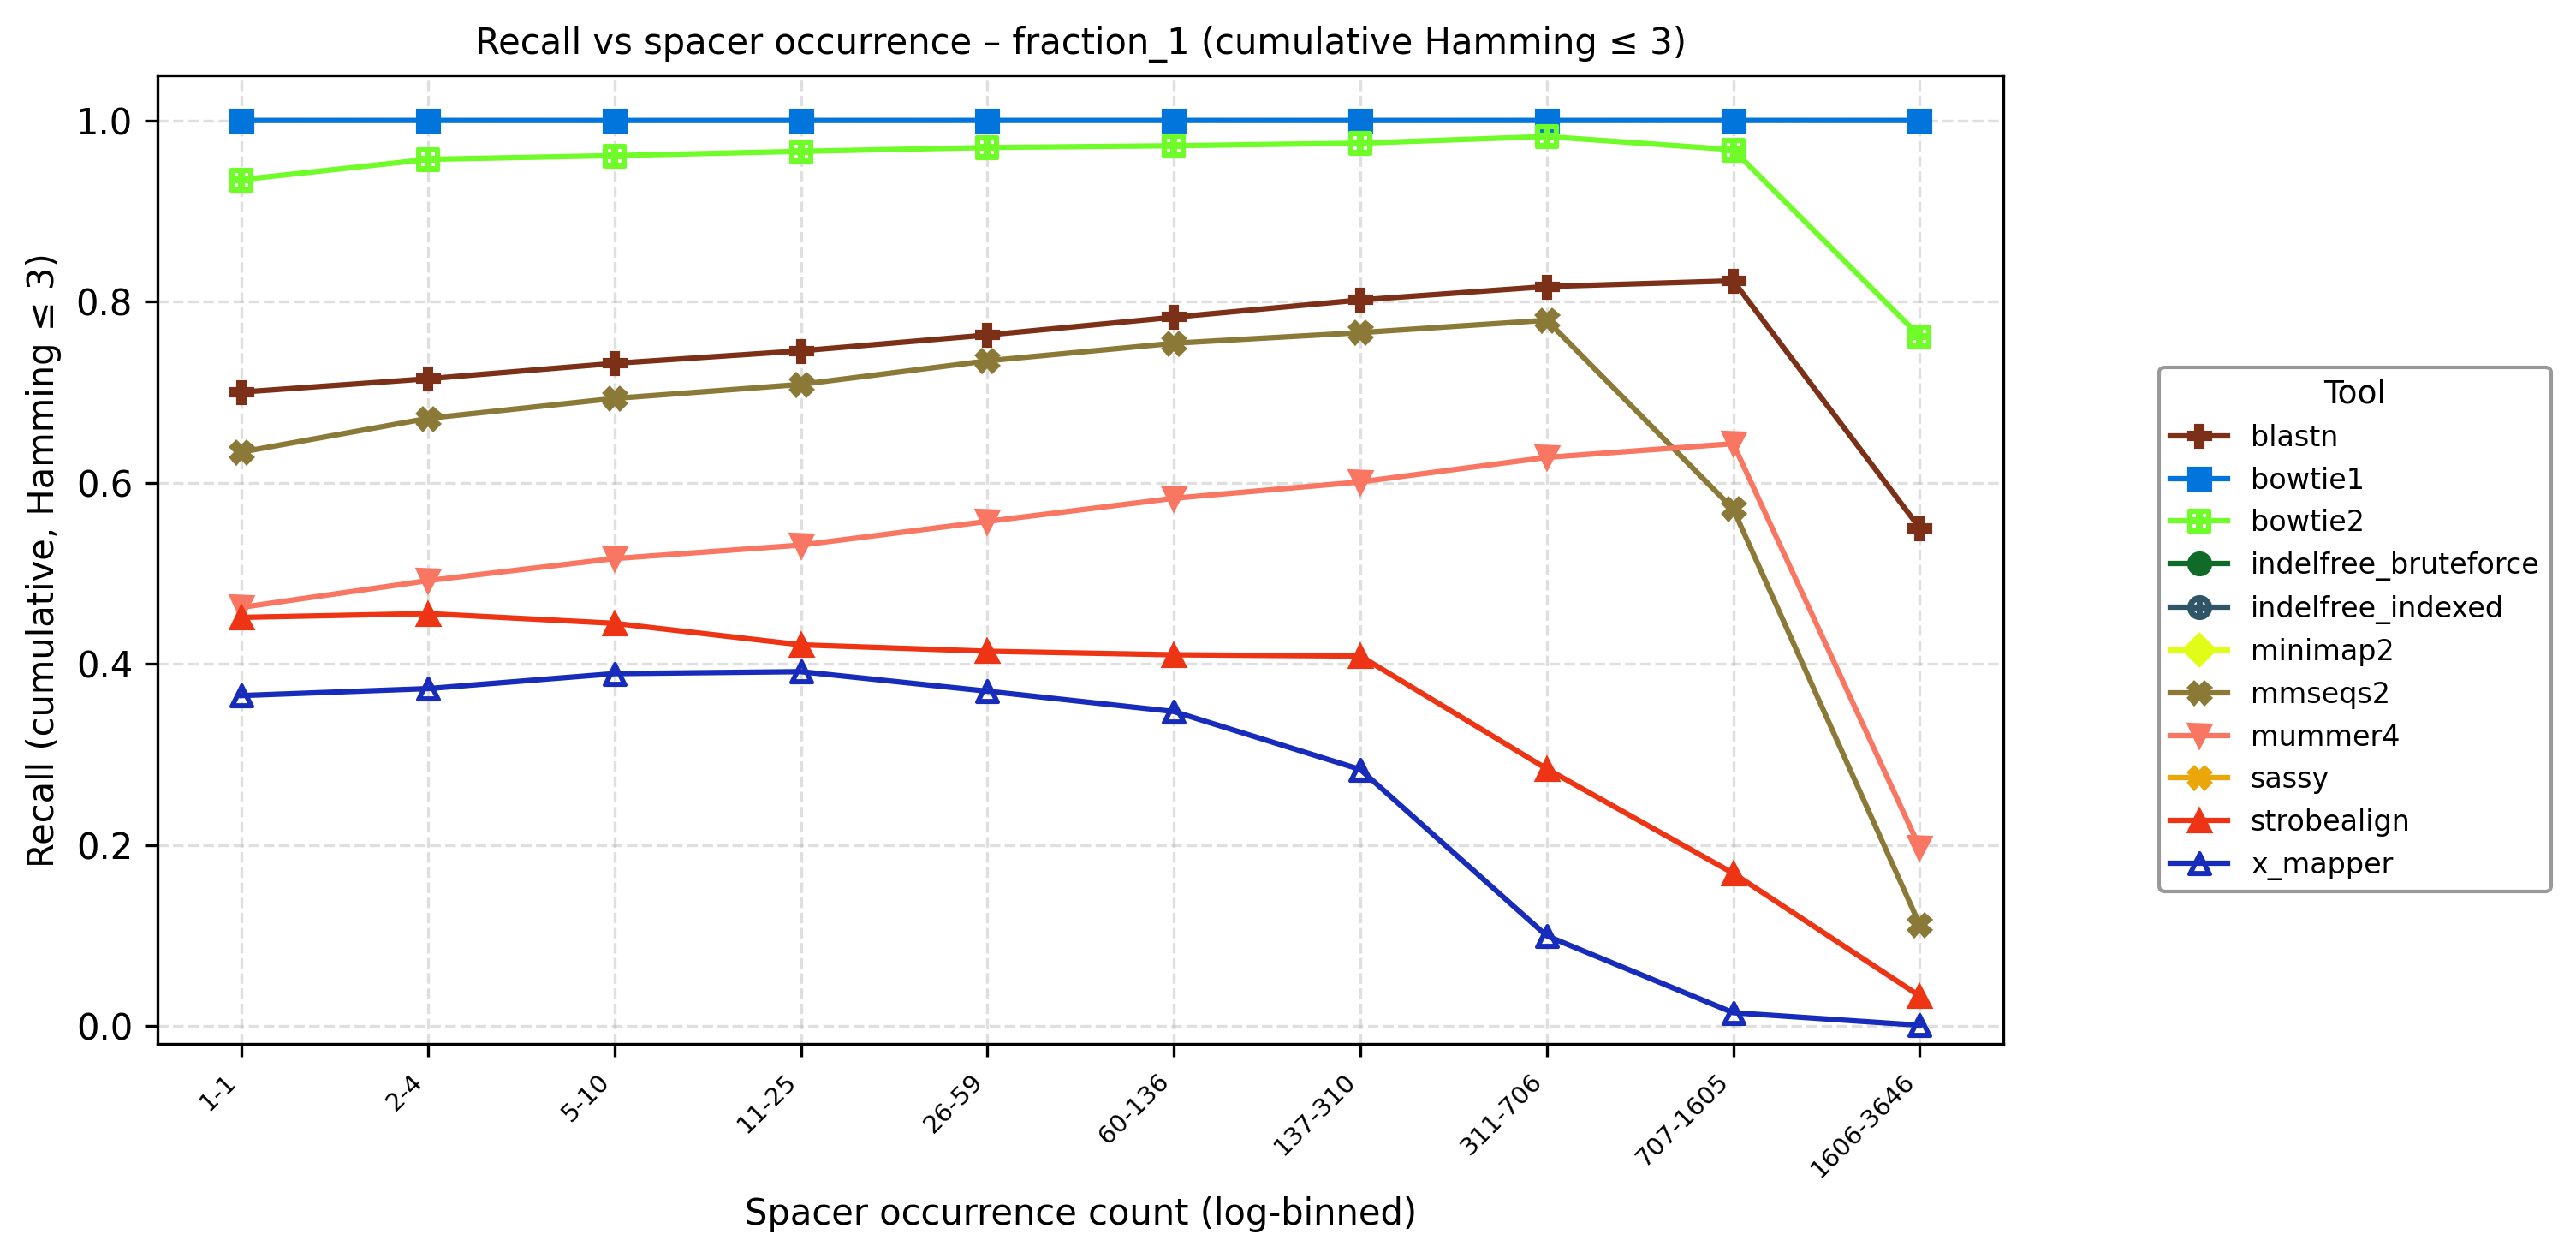{ .margin-caption }

### Supplementary Figure S4: Comparison of simulated vs real spacer characteristics

Distributions of spacer sequence features comparing simulated and real datasets, demonstrating that synthetic sequences approximate real data characteristics. Features analyzed include k-mer repeatability, Shannon entropy, base frequencies, GC content, and Local Composition Complexity (LCC, see https://doi.org/10.1038/npg.els.0005260 and https://github.com/biopython/biopython/blob/e451db211bdd855a5d0f1f6bba18985ffee12696/Bio/SeqUtils/lcc.py#L120 for details).

**A.** Filtered iPHoP spacer set:

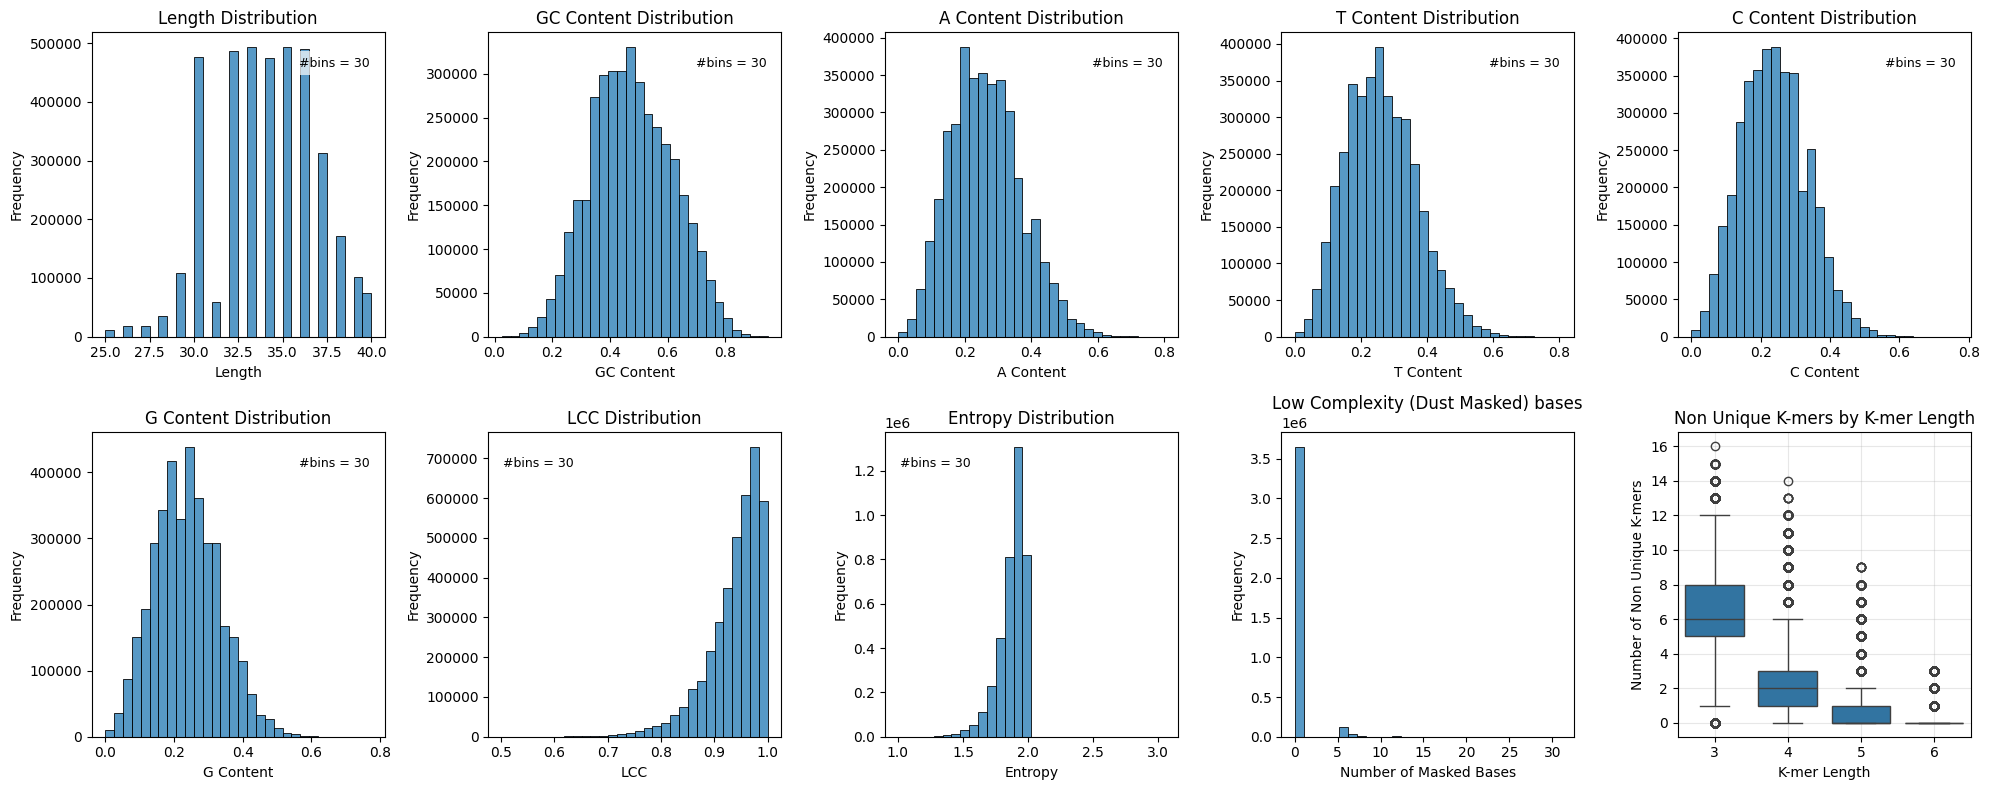{ .margin-caption }

**B.** Fully simulated spacer set (dataset: ns_100000_nc_20000):

{ .margin-caption }

### Supplementary Figure S5: Spacer characteristic distributions by dataset

Distributions of spacers characteristics for both real (IMG/VR4) and simulated datasets.  
(A) Spacer size (length in bp)  
(B) Mismatches observed in spacer alignments  
(C) Spacer occurrence rate.

#### 1. IMG/VR4 dataset (contig-side distributions)

Note: we removed outliers to enable plotting for the length (top left panel), see fraction_1 in Table S4 above.

{ .margin-caption }

### Supplementary Figure S6: Distribution of matched spacers from fraction_1

Distributions derived from the aggregate of all unique valid tool-reported alignments at hamming distance ≤3, from the results when scanning fraction_1 with the iPHoP spacer set. **A.** Length (bp) distribution of matched spacers. **B.** Total number of spacer occurrences (both axes are log-scaled), i.e. how many distinct contig regions each spacer aligned to. **C.** Number of reported unique alignments at each exact hamming distance value.

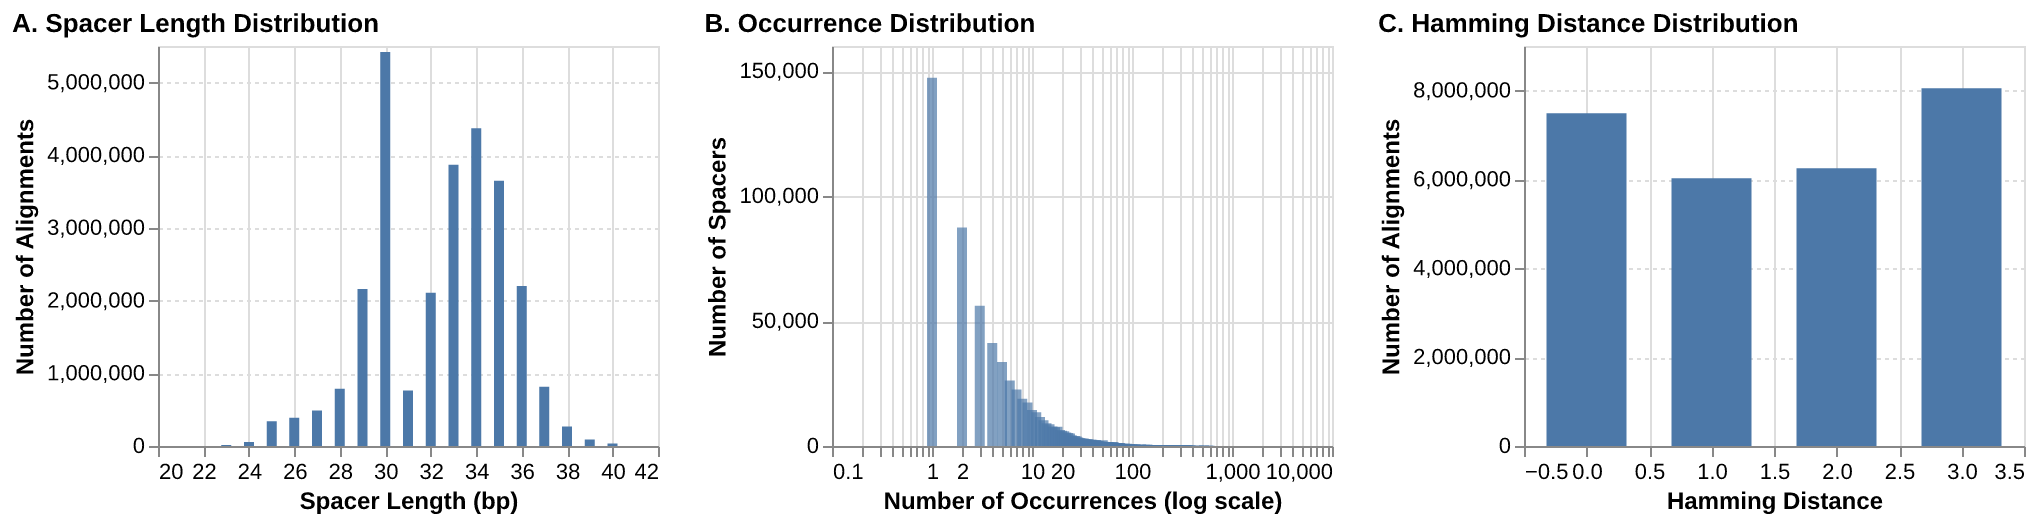{ .margin-caption }

### Supplementary Figure S7: Peak memory scaling (real and simulated datasets)

Peak memory usage (RSS, as reported by SLURM) scaling with dataset size. **A.** Real IMG/VR4 subsampled datasets (fractions 0.001-1.0). **B.** Simulated datasets with varying spacer and contig counts. Axes are log-scaled; tool identity is encoded by marker shape and color (see Table 1 in the main text for tool details).

{ .margin-caption }

### Supplementary Figure S8: Tool recall consistency across dataset sizes

Per-tool recall consistency at hamming distance ≤3. Upper panel: per-tool mean recall with error bars indicating standard deviation.

**A.** Real IMG/VR4 subsampled datasets. 

**B.** Fully synthetic datasets. 

**C.** Per-simulation (exact) recall values.  Heatmap of per-tool recall values across simulated datasets at Hamming distance ≤3. Rows correspond to tools and columns correspond to analyses runs.

## Supplementary Notes

### Supplementary Note 1: Coordinate Tolerance Matching Example

To illustrate the necessity for coordinate tolerance matching, consider the following case from one of the synthetic dataset (ns_100000_nc_10000) where three different tools detected the same ground truth region, but reported it with slightly different coordinates:

| Source | Spacer ID | Contig ID | Query Start | Query End | Target Start | Target End | Strand | Mismatches/Cost (tool-reported) | Notes |
|:-------|:-------|:-------|-------:|-------:|-------:|-------:|:-------|:-------|:-------|
| Ground Truth | 1c47e31b_spacer_10034 | 1c47e31b_contig_1828 | \- | \- | 5001 | 5036 | reverse | 1 |  |
| BLASTn | 1c47e31b_spacer_10034 | 1c47e31b_contig_1828 | 1 | 34 | 5036 | 5003 | reverse | 0 |  |
| MMseqs2 | 1c47e31b_spacer_10034 | 1c47e31b_contig_1828 | 1 | 35 | 5036 | 5002 | reverse | 1 |  |
| Sassy | 1c47e31b_spacer_10034 | 1c47e31b_contig_1828 | \- | \- | 5000 | 5036 | reverse | 1 | CIGAR: 34=1I1= |

In this example, BLASTn reports the ungapped alignment at contig positions 5003-5036 (0 reported mismatches), MMseqs2 reports 5002-5036 (1 reported mismatch over the terminal base), and Sassy reports 5000-5036 (1 reported insertion, suggesting the position 5000 in the contig matches that of the last position in the spacer). The ground truth planned occurrence was at 5001-5036. Despite these coordinate variations, all three tools detected the same biological match. **Critically**, all three tools report alignments that are acceptable matches to the ground truth occurrence, under a maximum hamming distance of 1.

This example demonstrates why a 5bp coordinate tolerance is necessary when aggregating results across tools to avoid double-counting essentially identical matches while accounting for valid algorithmic differences in gap versus substitution placement at alignment boundaries.

### Supplementary Note 2: Non-planned Match Rate Analysis

#### Hamming vs edit distance: per-simulation results

For each of the four fully synthetic simulations (ns_50000_nc_5000, ns_75000_nc_5000, ns_100000_nc_10000, ns_100000_nc_20000), we compared non-planned match counts under hamming distance (substitutions only) and edit distance (allowing indels) at thresholds 0 through 5.

##### Supplementary Figure S9: Per-simulation non-planned match counts (Hamming vs Edit)

Each panel below shows one simulation. Grouped bars compare hamming (blue) and edit (orange) distance non-planned match counts at each threshold (0–5, log scale). Annotations above each bar indicate exact counts.

###### A. ns_50000_nc_5000: 50,000 spacers (1.6 Mbp), 5,000 contigs (403 Mbp)

{ .margin-caption }

###### B. ns_75000_nc_5000: 75,000 spacers (2.4 Mbp), 5,000 contigs (401 Mbp)

{ .margin-caption }

###### C. ns_100000_nc_10000: 100,000 spacers (3.2 Mbp), 10,000 contigs (803 Mbp)

{ .margin-caption }

###### D. ns_100000_nc_20000: 100,000 spacers (3.2 Mbp), 20,000 contigs (1.6 Gbp)

{ .margin-caption }

#### Search-space-normalized non-planned match rates

##### Supplementary Table S7: Search-space-normalized metrics at hamming/edit distance ≤3

The table below summarizes the normalized non-planned match rates at distance threshold ≤3 for each simulation, extracted from the full dataset in `search_space_normalized_metrics.csv`. The threshold ≤3 subset is also available as `search_space_normalized_metrics_threshold3.csv`.

| Simulation | Metric | n_spacers | contig_bp (Gbp) | Non-planned | Per spacer per Gbp | Per Gbp$^2$ |
|:----------|:----------|----------:|----------:|----------:|----------:|----------:|
| ns_50000_nc_5000 | Hamming | 50,000 | 0.40 | 26 | 0.0013 | 40,371 |
| ns_50000_nc_5000 | Edit | 50,000 | 0.40 | 173 | 0.0086 | 268,621 |
| ns_75000_nc_5000 | Hamming | 75,000 | 0.40 | 39 | 0.0013 | 40,489 |
| ns_75000_nc_5000 | Edit | 75,000 | 0.40 | 280 | 0.0093 | 290,692 |
| ns_100000_nc_10000 | Hamming | 100,000 | 0.80 | 113 | 0.0014 | 43,968 |
| ns_100000_nc_10000 | Edit | 100,000 | 0.80 | 722 | 0.0090 | 280,929 |
| ns_100000_nc_20000 | Hamming | 100,000 | 1.60 | 187 | 0.0012 | 36,427 |
| ns_100000_nc_20000 | Edit | 100,000 | 1.60 | 1,393 | 0.0087 | 271,352 |

Non-planned match rates at distance threshold ≤3 for each fully synthetic simulation. The per Gbp$^2$ metric is consistent across simulations for both hamming (approximately 40,000) and edit (approximately 270,000–290,000) distance, confirming that this metric appropriately normalizes for search space size. Edit distance ≤3 produces approximately 6–8 fold more non-planned matches than hamming distance ≤3.

##### Supplementary Table S8: Semi-synthetic non-planned match rates by hamming threshold

| Hamming threshold | Non-planned matches | Per spacer per Gbp | Per Gbp$^2$ |
|------------------:|--------------------:|-------------------:|------------:|
|                 0 |                   1 |    6.1 × 10$^{-8}$ |        1.80 |
|                ≤1 |                  49 |    3.0 × 10$^{-6}$ |        88.2 |
|                ≤2 |               2,354 |    1.4 × 10$^{-4}$ |       4,236 |
|                ≤3 |              56,273 |    3.4 × 10$^{-3}$ |     101,270 |
|                ≤4 |              72,132 |    4.4 × 10$^{-3}$ |     129,810 |
|                ≤5 |             113,314 |    6.9 × 10$^{-3}$ |     203,922 |

Non-planned matches in the semi-synthetic dataset (3,826,979 real spacers × 421,431 simulated contigs, 0 planned spacer “injections”) at cumulative hamming distance thresholds. The per Gbp$^2$ rate at hamming ≤3 (101,270) is higher than observed in the fully synthetic datasets (approximately 40,000), which is expected given differences in sequence composition between real and simulated spacers (e.g., non-uniform k-mer distribution, biological sequence features). Values at thresholds ≤4 and ≤5 are **lower bounds** as only heuristic tools were used. {#tbl-supp-semisynthetic-rates} The comparison of normalized non-planned match rates between the semi-synthetic dataset and the mean across fully synthetic simulations at hamming distance ≤3 is presented in the main text (Table 3 in the main text).

#### Caveats and interpretation

These non-planned match rate estimates should be interpreted qualitatively rather than as exact predictive values. Real spacer sequences have compositional features (conserved motifs, non-random k-mer structure, locus-specific GC variation) not fully captured by simulated sequences, as illustrated by the approximately 2.5-fold difference between semi-synthetic and fully synthetic rates. Simulated contigs, while matched to IMG/VR4 in GC content and length distributions, lack additional structural features of real viral genomes (coding density, gene arrangement, horizontal transfer footprints) that may influence match frequencies. For the semi-synthetic dataset, only heuristic tools were computationally feasible, so the reported counts represent lower bounds on the true non-planned match frequency. These estimates are most informative for relative comparisons (hamming vs edit distance, threshold effects, and scaling with search space size); for absolute prediction of non-planned match counts in a given analysis, they should be treated as order-of-magnitude guides.

**Complete analysis available in:** `distance_metric_analysis_v3.ipynb` notebook in project repository, including per-distance breakdowns, tool-specific validation analyses, and detailed comparison tables.

## References and Data Availability

All analysis notebooks, source code, and generated data are available in the project repository at: [github.com/UriNeri/spacer_matching_bench](https://github.com/UriNeri/spacer_matching_bench).

Key analysis notebooks referenced in supplementary materials: - `spacer_inspection.ipynb`: Complexity filtering, spacer feature analysis, simulated vs real comparison - `distance_metric_analysis.ipynb`: Non-planned match rate analysis, coordinate tolerance examples, hamming vs edit distance comparison - `Prepare_all_jobs.ipynb`: Simulation parameter definitions, dataset generation commands - `Performance_simulated_v2.ipynb`: Per-tool performance metrics on simulated datasets - `Performance_imgvr4_v3.ipynb`: Per-tool performance metrics on real IMG/VR4 datasets

Dataset availability: - Filtered IMG/VR4 HQ contig subset (421,431 contigs, ~18.9 Gbp): \[Zenodo DOI\] - Filtered iPHoP spacer dataset (3,826,979 spacers, 132 Mbp): \[Zenodo DOI\] - All synthetic datasets and ground truth files: \[@zenodo_doi\]